# Credit Card Default Risk: PD Model, Expected Loss & Stress Testing

## Introduction

Credit risk management is a fundamental component of financial risk management, as financial institutions need to accurately assess the likelihood of borrower default and estimate potential losses arising from credit exposures.

The objective of this project is to develop an end-to-end credit risk modeling workflow that estimates borrower-level Probability of Default (PD) using machine learning techniques. The predicted PD is then calibrated and incorporated with Loss Given Default (LGD) and Exposure at Default (EAD) assumptions to estimate Expected Loss (EL):

\[
Expected\ Loss = PD \times LGD \times EAD
\]

The project covers key stages of a credit risk modeling process, including exploratory data analysis, feature engineering, model comparison, probability calibration, threshold analysis, risk segmentation, and scenario-based stress testing.

The workflow is designed as an educational implementation inspired by banking risk management practices, particularly Basel-style credit risk frameworks and portfolio monitoring processes. The objective is not only to maximize predictive performance but also to generate reliable risk estimates that can support credit decision-making and loss assessment.

## Data

This dataset contains information on default payments, demographic factors, credit data, history of payment, and bill statements of credit card clients in Taiwan from April 2005 to September 2005.

Sources: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/data

## Project Workflow

1. Data understanding  
2. Exploratory data analysis  
3. Data Processing and Logistic Regression Baseline 
4. Model Comparison 
5. Threshold Anaysis 
6. Expected Loss and Risk Segmentation  
7. Scenario-Based Stress Testing 

## 1. Data Understanding

This section checks the structure, variables, missing values, and target distribution of the dataset.


In [96]:
# =========================
# 1.1 Import Libraries
# =========================

import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
import matplotlib.ticker as ticker

from matplotlib.ticker import FuncFormatter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    log_loss
)

# VIF / multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor

try:
    from sklearn.frozen import FrozenEstimator
    frozen_estimator_available = True
except Exception:
    frozen_estimator_available = False
    
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
# =========================
# 1.2 Set Project Paths
# =========================

import os

# Local project setup (no Google Colab dependency)
# Place this notebook and the "Data" folder under the same PROJECT_PATH,
# or simply edit PROJECT_PATH below to point to your project folder.

PROJECT_PATH = "/Users/due/Library/CloudStorage/OneDrive-NationalEconomicsUniversity/Career Project/Credit Risk"

DATA_PATH = os.path.join(PROJECT_PATH, "Data", "default_credit_card_clients.xls")
OUTPUT_PATH = os.path.join(PROJECT_PATH, "Output")
REPORTS_PATH = os.path.join(PROJECT_PATH, "Reports")
DASHBOARD_PATH = os.path.join(PROJECT_PATH, "Dashboard")
NOTEBOOKS_PATH = os.path.join(PROJECT_PATH, "Notebooks")

for path in [OUTPUT_PATH, REPORTS_PATH, DASHBOARD_PATH]:
    os.makedirs(path, exist_ok=True)

print("File exists:", os.path.exists(DATA_PATH))
print(DATA_PATH)


File exists: True
/Users/due/Library/CloudStorage/OneDrive-NationalEconomicsUniversity/Career Project/Credit Risk/Data/default_credit_card_clients.xls


In [3]:
# =========================
# 1.3 Load Dataset
# =========================

df_raw = pd.read_excel(DATA_PATH, header=1)

print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)

df_raw.head()

Dataset loaded successfully.
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
# =========================
# 1.4 Create Working Copy
# =========================

df = df_raw.copy()

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
# =========================
# 1.5 Basic Data Inspection
# =========================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Number of rows: 30000
Number of columns: 25


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [7]:
# Missing values summary
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_rate": df.isnull().mean()
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_rate
ID,0,0.0000
BILL_AMT2,0,0.0000
PAY_AMT6,0,0.0000
PAY_AMT5,0,0.0000
PAY_AMT4,0,0.0000
PAY_AMT3,0,0.0000
PAY_AMT2,0,0.0000
PAY_AMT1,0,0.0000
BILL_AMT6,0,0.0000
BILL_AMT5,0,0.0000


In [8]:
# =========================
# 1.6 Rename Target Variable
# =========================

df = df.rename(columns={
    "default payment next month": "default"
})

target_col = "default"

df[[target_col]].head()

,default
0,1
1,1
2,0
3,0
4,0


In [9]:
# =========================
# 1.7 Target Distribution
# =========================

target_counts = df[target_col].value_counts().sort_index()
target_rates = df[target_col].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "rate": target_rates
})

target_summary

,count,rate
default,,
0,23364,0.7788
1,6636,0.2212


The target variable is moderately imbalanced. Most clients did not default, while a smaller but meaningful proportion defaulted in the next month. Therefore, model evaluation should not rely only on accuracy. ROC-AUC, recall, precision, and Gini coefficient will also be considered.


### Key Variables

| Variable Group | Columns | Description |
|---|---|---|
| Customer ID | `ID` | Unique customer identifier, excluded from modeling |
| Credit Limit | `LIMIT_BAL` | Approved credit limit, used as a credit exposure reference and sensitivity proxy |
| Demographics | `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` | Customer demographic information |
| Repayment Status | `PAY_0`, `PAY_2`, ..., `PAY_6` | Historical repayment status over recent months |
| Bill Amount | `BILL_AMT1`, ..., `BILL_AMT6` | Monthly bill statement amounts. `BILL_AMT1` is used as the main proxy for EAD in Expected Loss calculation |
| Payment Amount | `PAY_AMT1`, ..., `PAY_AMT6` | Monthly payment amounts |
| Target | `default` | Default payment indicator for the next month |

## 2. Exploratory Data Analysis

This section explores the relationship between borrower characteristics, credit exposure, repayment behavior, bill amounts, payment amounts, and default risk.

The EDA is designed to answer four key questions:

1. How imbalanced is the default target?
2. How does credit exposure differ between default and non-default clients?
3. How strongly is repayment delay associated with default risk?
4. What payment behavior patterns may help explain default?


In [10]:
# =========================
# 2.1 Target Distribution
# =========================

target_counts = df[target_col].value_counts().sort_index()
target_rates = df[target_col].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "rate": target_rates
})

target_summary


,count,rate
default,,
0,23364,0.7788
1,6636,0.2212


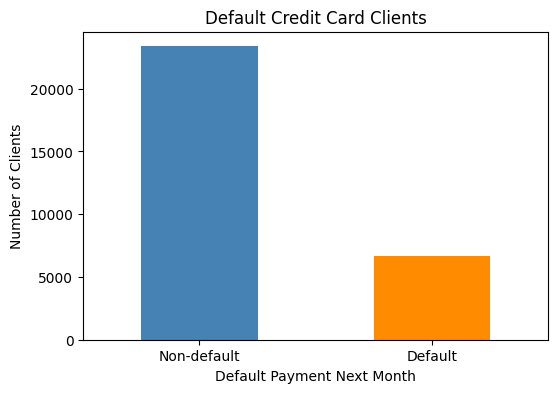

In [11]:
plt.figure(figsize=(6, 4))

target_counts.plot(kind="bar", color = ["steelblue", "darkorange"])

plt.title("Default Credit Card Clients")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Clients")
plt.xticks(ticks=[0, 1], labels=["Non-default", "Default"], rotation=0)

plt.show()

The target variable is imbalanced, with non-default customers representing the majority of observations. This imbalance is common in credit risk datasets, where default events are relatively rare compared with normal repayment behavior.

Therefore, evaluation metrics such as ROC-AUC, Recall, and calibration performance are considered more appropriate than accuracy alone.

In [ ]:
# =========================
# 2.2 Credit Limit Distribution
# =========================

df["LIMIT_BAL"].describe()

count      30,000.0000
mean      167,484.3227
std       129,747.6616
min        10,000.0000
25%        50,000.0000
50%       140,000.0000
75%       240,000.0000
max     1,000,000.0000
Name: LIMIT_BAL, dtype: float64

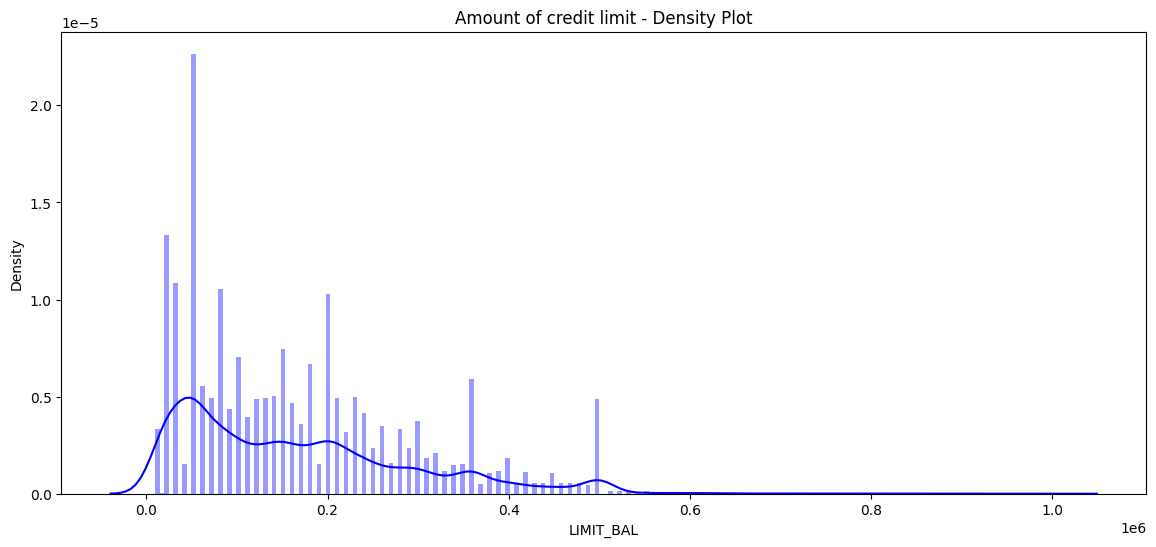

In [98]:

plt.figure(figsize=(14, 6))

plt.title("Amount of credit limit - Density Plot")

sns.set_color_codes("pastel")

sns.distplot(
    df["LIMIT_BAL"],
    kde=True,
    bins=200,
    color="blue"
)

plt.xlabel("LIMIT_BAL")
plt.ylabel("Density")

plt.show()


`LIMIT_BAL` represents the approved credit limit assigned to each customer by the financial institution.

The x-axis shows the credit limit amount in New Taiwan Dollars (NTD). The scientific notation on the axis means:

- `0.2 × 10^6` = 200,000 NTD
- `0.5 × 10^6` = 500,000 NTD
- `1.0 × 10^6` = 1,000,000 NTD

The distribution is highly right-skewed, indicating that most customers receive relatively lower credit limits, while a smaller group of customers has substantially higher assigned credit capacity.

From a credit risk perspective, `LIMIT_BAL` represents the customer's approved borrowing capacity rather than the actual outstanding exposure. Therefore, it is used as a credit capacity indicator in the model. For Expected Loss calculation, `BILL_AMT1` is selected as a simplified proxy for Exposure at Default (EAD) because it better reflects the customer's current outstanding balance.

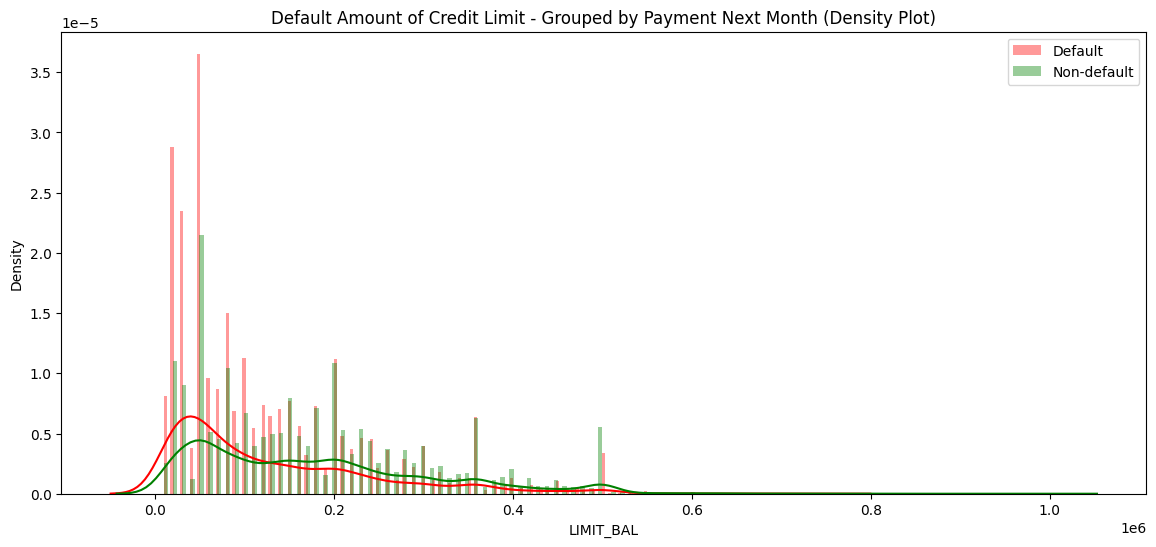

In [ ]:
# =========================
# 2.3 Credit Limit by Default Status 
# =========================

class_0 = df.loc[df[target_col] == 0, "LIMIT_BAL"]
class_1 = df.loc[df[target_col] == 1, "LIMIT_BAL"]

plt.figure(figsize=(14, 6))

plt.title("Default Amount of Credit Limit - Grouped by Payment Next Month (Density Plot)")

sns.set_color_codes("pastel")

sns.distplot(
    class_1,
    kde=True,
    bins=200,
    color="red",
    label="Default"
)

sns.distplot(
    class_0,
    kde=True,
    bins=200,
    color="green",
    label="Non-default"
)

plt.xlabel("LIMIT_BAL")
plt.ylabel("Density")
plt.legend()

plt.show()


This density plot compares the distribution of assigned credit limits (`LIMIT_BAL`) between default and non-default customers.

The x-axis represents the approved credit limit in New Taiwan Dollars (NTD), while the y-axis represents probability density. A higher density indicates a higher concentration of customers within a specific credit limit range rather than the absolute number of customers.

The distributions show that default customers are more concentrated in the lower credit limit range compared with non-default customers. This suggests that customers with relatively lower assigned credit limits may represent a higher-risk segment in this dataset.

However, the two distributions overlap substantially across most credit limit ranges, indicating that `LIMIT_BAL` alone is not sufficient to distinguish default and non-default customers. Credit limit should therefore be considered together with other risk-related variables, particularly repayment behavior (`PAY_0` - `PAY_6`), bill amounts, and payment history.

From a credit risk perspective, `LIMIT_BAL` mainly reflects the customer's approved borrowing capacity rather than actual outstanding exposure. Therefore, it is used as a credit profile indicator in the model, while `BILL_AMT1` is later considered as a simplified proxy for Exposure at Default (EAD) in Expected Loss estimation.

In [15]:
# =========================
# 2.4 Credit Limit by Default Status
# =========================

df.groupby(target_col)["LIMIT_BAL"].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,"23,364.0000","178,099.7261","131,628.3597","10,000.0000","70,000.0000","150,000.0000","250,000.0000","1,000,000.0000"
1,"6,636.0000","130,109.6564","115,378.5406","10,000.0000","50,000.0000","90,000.0000","200,000.0000","740,000.0000"


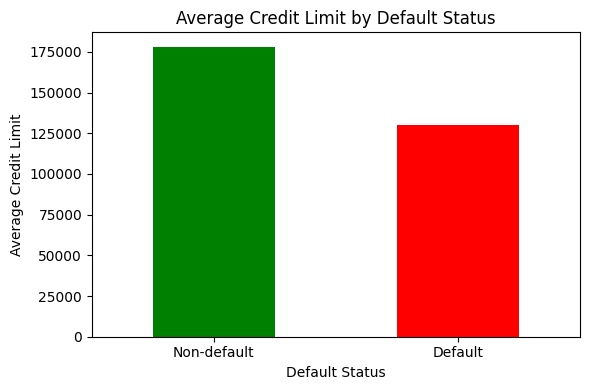

In [16]:
limit_default_summary = df.groupby(target_col)["LIMIT_BAL"].mean()

plt.figure(figsize=(6, 4))

limit_default_summary.plot(
    kind="bar",
    color=["green", "red"]
)

plt.title("Average Credit Limit by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Average Credit Limit")
plt.xticks(ticks=[0, 1], labels=["Non-default", "Default"], rotation=0)

plt.tight_layout()
plt.show()

Credit limit differs between default and non-default clients. Although `LIMIT_BAL` is not used as the main EAD proxy in the final Expected Loss calculation, it remains useful for understanding customer credit capacity and for sensitivity comparison.

In [17]:
# =========================
# 2.5 Default Rate by Demographic Variables
# =========================

def default_rate_by_category(data, category_col, target_col="default"):
    summary = (
        data.groupby(category_col)[target_col]
        .agg(["count", "mean"])
        .rename(columns={"mean": "default_rate"})
        .sort_index()
    )

    display(summary)

    plt.figure(figsize=(7, 4))
    summary["default_rate"].plot(kind="bar")
    plt.title(f"Default Rate by {category_col}")
    plt.xlabel(category_col)
    plt.ylabel("Default Rate")
    plt.xticks(rotation=0)
    plt.show()

,count,default_rate
SEX,,
1,11888,0.2417
2,18112,0.2078


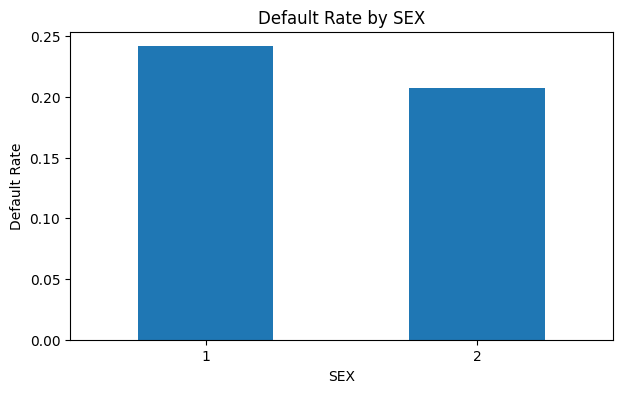

,count,default_rate
EDUCATION,,
0,14,0.0000
1,10585,0.1923
2,14030,0.2373
3,4917,0.2516
4,123,0.0569
5,280,0.0643
6,51,0.1569


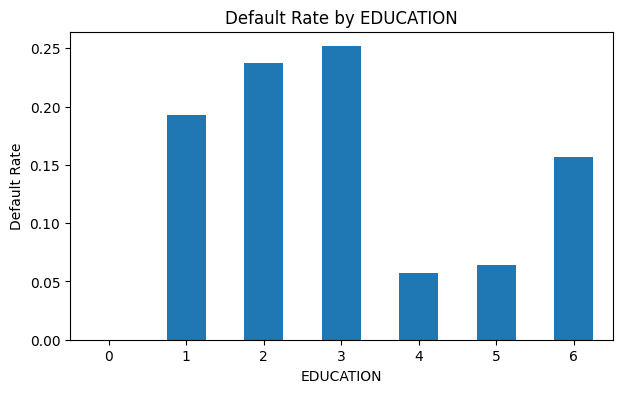

,count,default_rate
MARRIAGE,,
0,54,0.0926
1,13659,0.2347
2,15964,0.2093
3,323,0.2601


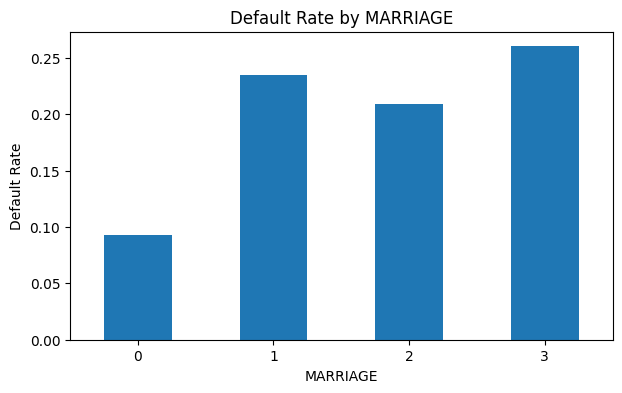

In [18]:
default_rate_by_category(df, "SEX", target_col)
default_rate_by_category(df, "EDUCATION", target_col)
default_rate_by_category(df, "MARRIAGE", target_col)

In [19]:
# =========================
# 2.6 Default Rate by Repayment Status
# =========================

pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in pay_status_cols:
    print(f"\nDefault rate by {col}")
    summary = (
        df.groupby(col)[target_col]
        .agg(["count", "mean"])
        .rename(columns={"mean": "default_rate"})
        .sort_index()
    )
    display(summary)


Default rate by PAY_0


,count,default_rate
PAY_0,,
-2,2759,0.1323
-1,5686,0.1678
0,14737,0.1281
1,3688,0.3395
2,2667,0.6914
3,322,0.7578
4,76,0.6842
5,26,0.5000
6,11,0.5455



Default rate by PAY_2


,count,default_rate
PAY_2,,
-2,3782,0.1827
-1,6050,0.1597
0,15730,0.1591
1,28,0.1786
2,3927,0.5561
3,326,0.6166
4,99,0.5051
5,25,0.6000
6,12,0.7500



Default rate by PAY_3


...

,count,default_rate
PAY_4,,
-2,4348,0.1925
-1,5687,0.1590
0,16455,0.1833
1,2,0.5000
2,3159,0.5233
3,180,0.6111
4,69,0.6667
5,35,0.5143
6,5,0.4000



Default rate by PAY_5


,count,default_rate
PAY_5,,
-2,4546,0.1969
-1,5539,0.1619
0,16947,0.1885
2,2626,0.5419
3,178,0.6348
4,84,0.6071
5,17,0.5882
6,4,0.7500
7,58,0.8276



Default rate by PAY_6


,count,default_rate
PAY_6,,
-2,4895,0.2004
-1,5740,0.1699
0,16286,0.1884
2,2766,0.5065
3,184,0.6413
4,49,0.6327
5,13,0.5385
6,19,0.7368
7,46,0.8261


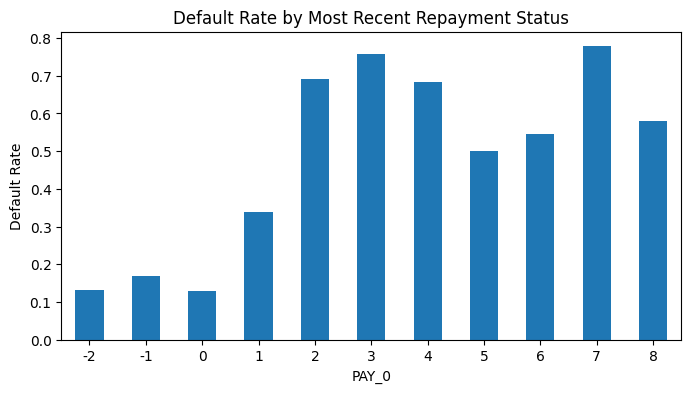

In [20]:
pay0_default_rate = df.groupby("PAY_0")[target_col].mean().sort_index()

plt.figure(figsize=(8, 4))
pay0_default_rate.plot(kind="bar")
plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("PAY_0")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.show()

In [21]:
# =========================
# 2.7 Correlation among Bill Amount Variables
# =========================

bill_amt_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

bill_corr = df[bill_amt_cols].corr()
bill_corr

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
BILL_AMT1,1.0000,0.9515,0.8923,0.8603,0.8298,0.8027
BILL_AMT2,0.9515,1.0000,0.9283,0.8925,0.8598,0.8316
BILL_AMT3,0.8923,0.9283,1.0000,0.9240,0.8839,0.8533
BILL_AMT4,0.8603,0.8925,0.9240,1.0000,0.9401,0.9009
BILL_AMT5,0.8298,0.8598,0.8839,0.9401,1.0000,0.9462
BILL_AMT6,0.8027,0.8316,0.8533,0.9009,0.9462,1.0000


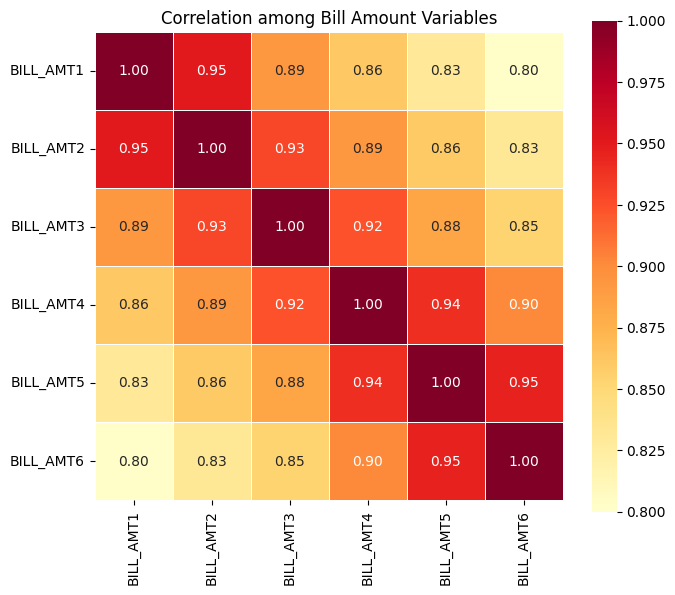

In [22]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    bill_corr,
    annot=True,          
    fmt=".2f",
    cmap="YlOrRd",      
    vmin=0.8, vmax=1.0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation among Bill Amount Variables")
plt.tight_layout()
plt.show()

In [23]:
# =========================
# 2.8 Correlation among Payment Amount Variables
# =========================

pay_amt_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

pay_amt_corr = df[pay_amt_cols].corr()
pay_amt_corr

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
PAY_AMT1,1.0000,0.2856,0.2522,0.1996,0.1485,0.1857
PAY_AMT2,0.2856,1.0000,0.2448,0.1801,0.1809,0.1576
PAY_AMT3,0.2522,0.2448,1.0000,0.2163,0.1592,0.1627
PAY_AMT4,0.1996,0.1801,0.2163,1.0000,0.1518,0.1578
PAY_AMT5,0.1485,0.1809,0.1592,0.1518,1.0000,0.1549
PAY_AMT6,0.1857,0.1576,0.1627,0.1578,0.1549,1.0000


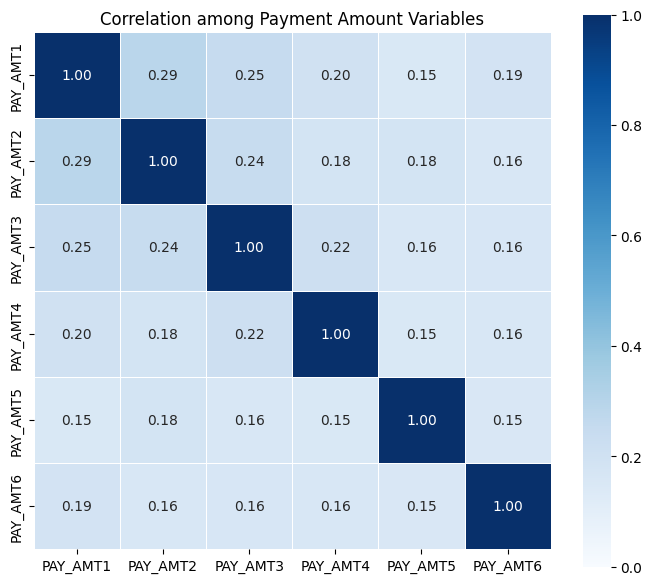

In [24]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    pay_amt_corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0, vmax=1.0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation among Payment Amount Variables")
plt.tight_layout()
plt.show()

In [25]:
# =========================
# 2.9 Correlation among Repayment Status Variables
# =========================

pay_status_corr = df[pay_status_cols].corr()
pay_status_corr

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
PAY_0,1.0000,0.6722,0.5742,0.5388,0.5094,0.4746
PAY_2,0.6722,1.0000,0.7666,0.6621,0.6228,0.5755
PAY_3,0.5742,0.7666,1.0000,0.7774,0.6868,0.6327
PAY_4,0.5388,0.6621,0.7774,1.0000,0.8198,0.7164
PAY_5,0.5094,0.6228,0.6868,0.8198,1.0000,0.8169
PAY_6,0.4746,0.5755,0.6327,0.7164,0.8169,1.0000


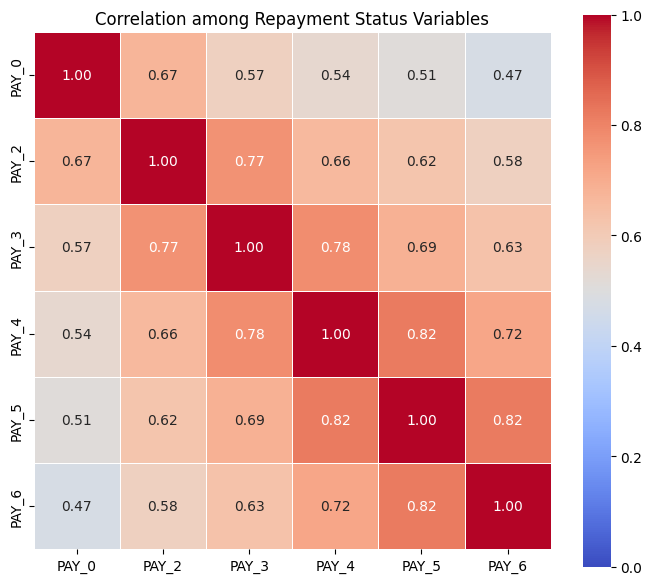

In [26]:

plt.figure(figsize=(7, 6))
sns.heatmap(
    pay_status_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0, vmax=1.0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation among Repayment Status Variables")
plt.tight_layout()
plt.show()

In [27]:
# =========================
# 2.10 Initial VIF Check on Raw Numeric Variables
# =========================

numeric_features_for_vif = df.select_dtypes(
    include=["int64", "float64"]
).drop(
    columns=["ID", target_col],
    errors="ignore"
)

# Remove columns with only one unique value
numeric_features_for_vif = numeric_features_for_vif.loc[
    :,
    numeric_features_for_vif.nunique() > 1
]

print("Number of numeric features used for VIF:", numeric_features_for_vif.shape[1])

numeric_features_for_vif.head()

Number of numeric features used for VIF: 23


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [28]:

imputer = SimpleImputer(strategy="median")
X_vif_imputed = imputer.fit_transform(numeric_features_for_vif)

# Scale variables for numerical stability
scaler = StandardScaler()
X_vif_scaled = scaler.fit_transform(X_vif_imputed)

vif_data = pd.DataFrame({
    "feature": numeric_features_for_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif_scaled, i)
        for i in range(X_vif_scaled.shape[1])
    ]
})

vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

vif_data

,feature,VIF
0,BILL_AMT2,25.8649
1,BILL_AMT5,24.9967
2,BILL_AMT3,21.7757
3,BILL_AMT4,20.3468
4,BILL_AMT6,15.0248
5,BILL_AMT1,14.0327
6,PAY_5,4.7251
7,PAY_4,4.2874
8,PAY_3,3.6575
9,PAY_6,3.2562


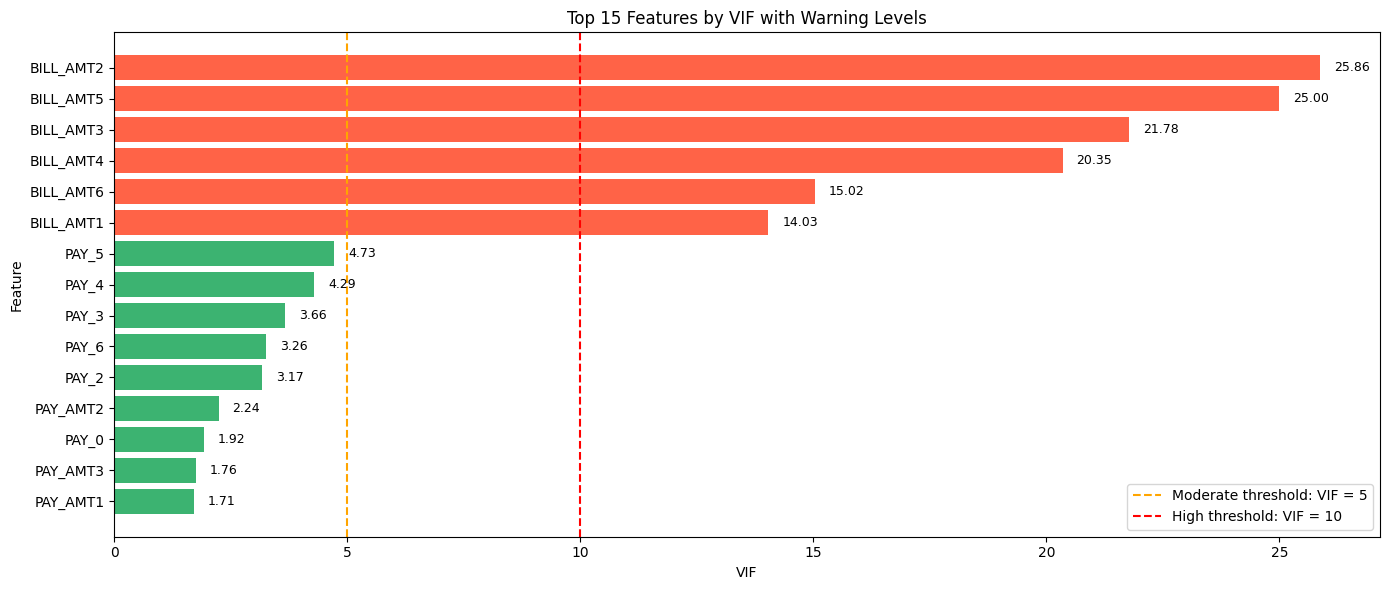

In [29]:
def classify_vif(vif):
    if vif < 5:
        return "Low"
    elif vif < 10:
        return "Moderate"
    else:
        return "High"

# Add VIF warning level
vif_data["VIF_Level"] = vif_data["VIF"].apply(classify_vif)

# Select top 15 highest VIF features
top_vif = vif_data.head(15).sort_values("VIF")

# Color mapping
color_map = {
    "Low": "mediumseagreen",
    "Moderate": "orange",
    "High": "tomato"
}

bar_colors = top_vif["VIF_Level"].map(color_map)

plt.figure(figsize=(14, 6))

bars = plt.barh(
    top_vif["feature"],
    top_vif["VIF"],
    color=bar_colors
)

# Warning threshold lines
plt.axvline(
    x=5,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="Moderate threshold: VIF = 5"
)

plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="High threshold: VIF = 10"
)

# Add VIF value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

plt.title("Top 15 Features by VIF with Warning Levels")
plt.xlabel("VIF")
plt.ylabel("Feature")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [30]:
# =========================
# 2.11 Correlation with Default
# =========================

corr_with_default = df.corr(numeric_only=True)[target_col].sort_values(ascending=False)

corr_with_default

default      1.0000
PAY_0        0.3248
PAY_2        0.2636
PAY_3        0.2353
PAY_4        0.2166
PAY_5        0.2041
PAY_6        0.1869
EDUCATION    0.0280
AGE          0.0139
BILL_AMT6   -0.0054
BILL_AMT5   -0.0068
BILL_AMT4   -0.0102
ID          -0.0140
BILL_AMT3   -0.0141
BILL_AMT2   -0.0142
BILL_AMT1   -0.0196
MARRIAGE    -0.0243
SEX         -0.0400
PAY_AMT6    -0.0532
PAY_AMT5    -0.0551
PAY_AMT3    -0.0563
PAY_AMT4    -0.0568
PAY_AMT2    -0.0586
PAY_AMT1    -0.0729
LIMIT_BAL   -0.1535
Name: default, dtype: float64

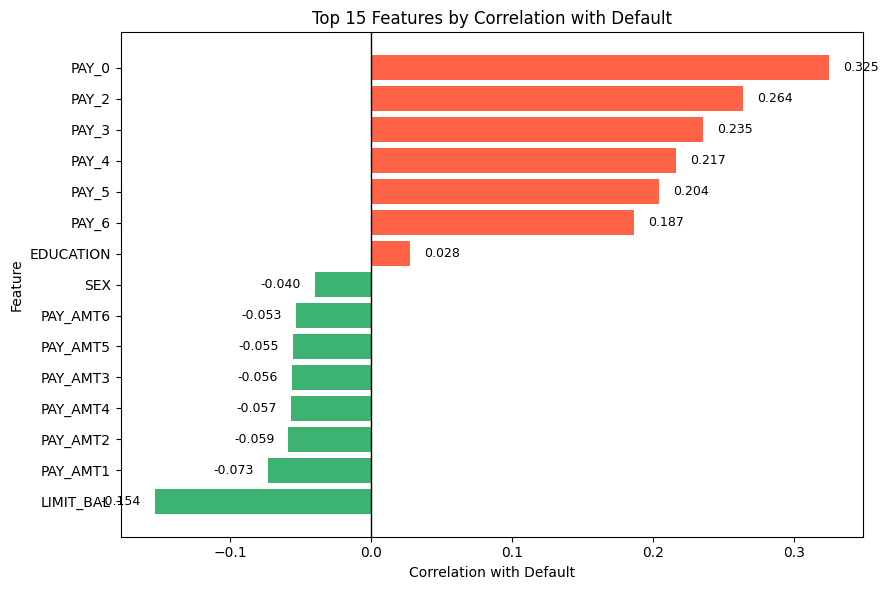

In [31]:
corr_with_default = (
    df.corr(numeric_only=True)[target_col]
    .drop(target_col)
)

top_corr = (
    corr_with_default
    .reindex(corr_with_default.abs().sort_values(ascending=False).head(15).index)
    .sort_values()
)

colors = [
    "tomato" if value > 0 else "mediumseagreen"
    for value in top_corr
]

plt.figure(figsize=(9, 6))

bars = plt.barh(
    top_corr.index,
    top_corr.values,
    color=colors
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title("Top 15 Features by Correlation with Default")
plt.xlabel("Correlation with Default")
plt.ylabel("Feature")

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01 if width > 0 else width - 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left" if width > 0 else "right",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [32]:
# =========================
# 2.12 Behavior Feature Engineering 
# =========================


The original dataset contains monthly repayment status, bill amount, and payment amount variables for the past six months. To summarize customer behavior over time, several behavioral features are created.

| Feature | Formula | Interpretation |
|---|---|---|
| `avg_pay_status` | Average of `PAY_0`, `PAY_2`, ..., `PAY_6` | Measures the customer's average repayment delay over the past six months |
| `avg_bill_amt` | Average of `BILL_AMT1`, ..., `BILL_AMT6` | Measures the customer's average outstanding bill amount |
| `avg_pay_amt` | Average of `PAY_AMT1`, ..., `PAY_AMT6` | Measures the customer's average repayment amount |
| `credit_utilization` | `avg_bill_amt / LIMIT_BAL` | Measures how much of the credit limit is being used |
| `payment_to_bill_ratio` | `avg_pay_amt / avg_bill_amt` | Measures how much the customer repays relative to the outstanding bill |

These features are designed to capture repayment behavior, credit usage, and repayment capacity, which are important signals for Probability of Default modeling.

In [33]:
df["avg_pay_status"] = df[pay_status_cols].mean(axis=1)
df["avg_bill_amt"] = df[bill_amt_cols].mean(axis=1)
df["avg_pay_amt"] = df[pay_amt_cols].mean(axis=1)

df["credit_utilization"] = df["avg_bill_amt"] / df["LIMIT_BAL"]

df["payment_to_bill_ratio"] = (
    df["avg_pay_amt"] / df["avg_bill_amt"].replace(0, np.nan)
)

df["payment_to_bill_ratio"] = df["payment_to_bill_ratio"].replace(
    [np.inf, -np.inf], np.nan
)

df[
    [
        "avg_pay_status",
        "avg_bill_amt",
        "avg_pay_amt",
        "credit_utilization",
        "payment_to_bill_ratio",
        target_col
    ]
].head()

,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio,default
0,-0.3333,"1,284.0000",114.8333,0.0642,0.0894,1
1,0.5000,"2,846.1667",833.3333,0.0237,0.2928,1
2,0.0000,"16,942.1667","1,836.3333",0.1882,0.1084,0
3,0.0000,"38,555.6667","1,398.0000",0.7711,0.0363,0
4,-0.3333,"18,223.1667","9,841.5000",0.3645,0.5401,0


In [34]:
behavior_summary = df.groupby(target_col)[
    [
        "avg_pay_status",
        "avg_bill_amt",
        "avg_pay_amt",
        "credit_utilization",
        "payment_to_bill_ratio"
    ]
].median()

behavior_summary

,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio
default,,,,,
0,0.0000,"21,443.4167","2,754.0000",0.2416,0.1175
1,0.3333,"19,781.3333","1,612.4167",0.4627,0.0590


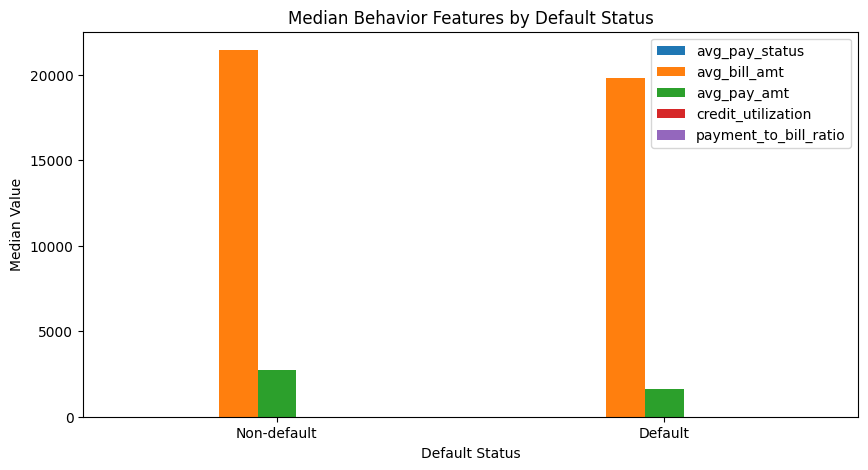

In [35]:
behavior_summary.plot(kind="bar", figsize=(10, 5))

plt.title("Median Behavior Features by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Median Value")
plt.xticks(ticks=[0, 1], labels=["Non-default", "Default"], rotation=0)

plt.show()

## 3. Data Processing and Logistic Regression Baseline

This section prepares the dataset for Probability of Default modeling and builds a baseline Logistic Regression model.

Logistic Regression is used as the baseline model because it is interpretable and commonly used in credit risk modeling. The model output is interpreted as borrower-level Probability of Default (PD).

To reduce multicollinearity and improve model interpretability, the modeling dataset uses a reduced feature set instead of all raw monthly variables.

The original monthly bill amount variables, payment amount variables, and older repayment status variables are highly correlated with each other. Therefore, they are summarized into engineered behavior features.

The final modeling feature set keeps:

- Demographic variables: `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`
- Credit exposure variable: `LIMIT_BAL`
- Recent repayment status: `PAY_0`
- Engineered behavior features: `avg_pay_status`, `avg_bill_amt`, `avg_pay_amt`, `credit_utilization`, `payment_to_bill_ratio`

`PAY_0` is retained because recent repayment behavior is highly relevant for next-month default risk. Other monthly variables are excluded to make the model more stable and easier to explain.

In [36]:
# =========================
# 3.1 Create Reduced Modeling Dataset
# =========================

df_model = df.copy()

# Replace infinite values with NaN
df_model = df_model.replace([np.inf, -np.inf], np.nan)

# Group undocumented education categories into 'Others'
df_model["EDUCATION"] = df_model["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

# Group undocumented marriage category into 'Others'
df_model["MARRIAGE"] = df_model["MARRIAGE"].replace({
    0: 3
})

# Explicitly select the final modeling features
modeling_features = [
    # Demographics and exposure
    "LIMIT_BAL",
    "AGE",
    "SEX",
    "EDUCATION",
    "MARRIAGE",

    # Most recent repayment status
    "PAY_0",

    # Engineered behavior features
    "avg_pay_status",
    "avg_bill_amt",
    "avg_pay_amt",
    "credit_utilization",
    "payment_to_bill_ratio"
]

# Keep only ID, selected features, and target in the modeling dataset
df_model = df_model[["ID"] + modeling_features + [target_col]].copy()

print("EDUCATION values:", sorted(df_model["EDUCATION"].unique()))
print("MARRIAGE values :", sorted(df_model["MARRIAGE"].unique()))
print("Modeling dataset shape:", df_model.shape)

print("\nFeatures selected for modeling:")
for feature in modeling_features:
    print("-", feature)

display(df_model.head())

EDUCATION values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE values : [np.int64(1), np.int64(2), np.int64(3)]
Modeling dataset shape: (30000, 13)

Features selected for modeling:
- LIMIT_BAL
- AGE
- SEX
- EDUCATION
- MARRIAGE
- PAY_0
- avg_pay_status
- avg_bill_amt
- avg_pay_amt
- credit_utilization
- payment_to_bill_ratio


,ID,LIMIT_BAL,AGE,SEX,EDUCATION,MARRIAGE,PAY_0,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio,default
0,1,20000,24,2,2,1,2,-0.3333,"1,284.0000",114.8333,0.0642,0.0894,1
1,2,120000,26,2,2,2,-1,0.5000,"2,846.1667",833.3333,0.0237,0.2928,1
2,3,90000,34,2,2,2,0,0.0000,"16,942.1667","1,836.3333",0.1882,0.1084,0
3,4,50000,37,2,2,1,0,0.0000,"38,555.6667","1,398.0000",0.7711,0.0363,0
4,5,50000,57,1,2,1,-1,-0.3333,"18,223.1667","9,841.5000",0.3645,0.5401,0


In [37]:
print("Modeling dataset shape:", df_model.shape)
df_model.head()

Modeling dataset shape: (30000, 13)


,ID,LIMIT_BAL,AGE,SEX,EDUCATION,MARRIAGE,PAY_0,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio,default
0,1,20000,24,2,2,1,2,-0.3333,"1,284.0000",114.8333,0.0642,0.0894,1
1,2,120000,26,2,2,2,-1,0.5000,"2,846.1667",833.3333,0.0237,0.2928,1
2,3,90000,34,2,2,2,0,0.0000,"16,942.1667","1,836.3333",0.1882,0.1084,0
3,4,50000,37,2,2,1,0,0.0000,"38,555.6667","1,398.0000",0.7711,0.0363,0
4,5,50000,57,1,2,1,-1,-0.3333,"18,223.1667","9,841.5000",0.3645,0.5401,0


A separate modeling dataset is created from the EDA dataset. Infinite values are replaced with missing values so that they can be handled properly during preprocessing.

In [38]:
# =========================
# 3.2 Define Features and Target
# =========================

X = df_model[modeling_features].copy()
y = df_model[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (30000, 11)
y shape: (30000,)


,LIMIT_BAL,AGE,SEX,EDUCATION,MARRIAGE,PAY_0,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio
0,20000,24,2,2,1,2,-0.3333,"1,284.0000",114.8333,0.0642,0.0894
1,120000,26,2,2,2,-1,0.5000,"2,846.1667",833.3333,0.0237,0.2928
2,90000,34,2,2,2,0,0.0000,"16,942.1667","1,836.3333",0.1882,0.1084
3,50000,37,2,2,1,0,0.0000,"38,555.6667","1,398.0000",0.7711,0.0363
4,50000,57,1,2,1,-1,-0.3333,"18,223.1667","9,841.5000",0.3645,0.5401


The `ID` column is removed because it is only a customer identifier and does not contain predictive information. The target variable is `default`, while the remaining variables are used as model features.

In [39]:
# =========================
# 3.3 Define Numeric and Categorical Features
# =========================

categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]

numeric_features = [
    feature for feature in modeling_features
    if feature not in categorical_features
]

print("Numeric features:")
for feature in numeric_features:
    print("-", feature)

print("\nCategorical features:")
for feature in categorical_features:
    print("-", feature)

Numeric features:
- LIMIT_BAL
- AGE
- PAY_0
- avg_pay_status
- avg_bill_amt
- avg_pay_amt
- credit_utilization
- payment_to_bill_ratio

Categorical features:
- SEX
- EDUCATION
- MARRIAGE


In [40]:
# =========================
# 3.4 VIF on Final Modeling Features
# =========================

X_vif = df_model[numeric_features].copy()

# Replace infinite values with NaN
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)

# Fill missing values with median
X_vif = X_vif.fillna(X_vif.median())

# Scale variables for numerical stability
X_vif_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_vif),
    columns=numeric_features
)

vif_data = pd.DataFrame({
    "feature": X_vif_scaled.columns,
    "VIF": [
        variance_inflation_factor(X_vif_scaled.values, i)
        for i in range(X_vif_scaled.shape[1])
    ]
})

vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif_data)

print("VIF check completed on final numeric modeling features.")

,feature,VIF
0,credit_utilization,3.0159
1,avg_pay_status,2.7074
2,avg_bill_amt,2.6608
3,PAY_0,2.2435
4,LIMIT_BAL,2.2389
5,avg_pay_amt,1.2455
6,AGE,1.0227
7,payment_to_bill_ratio,1.0028


VIF check completed on final numeric modeling features.


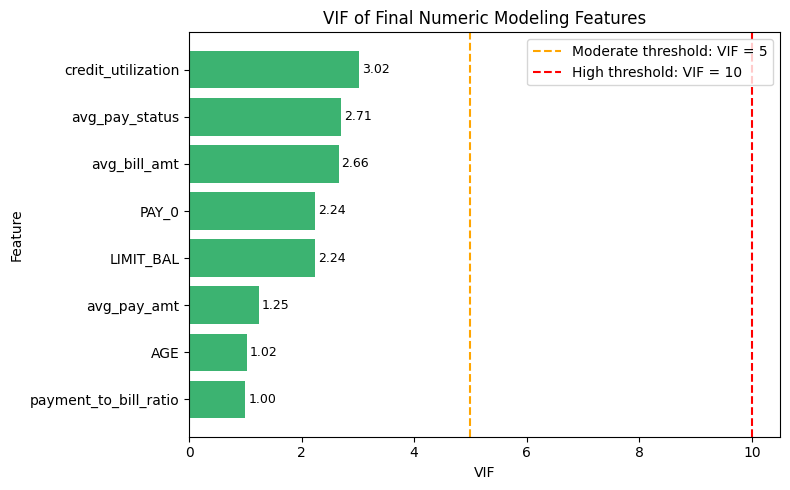

In [41]:

vif_plot = vif_data.sort_values("VIF", ascending=True)

def assign_vif_color(vif):
    if vif >= 10:
        return "tomato"
    elif vif >= 5:
        return "orange"
    else:
        return "mediumseagreen"

colors = vif_plot["VIF"].apply(assign_vif_color)

plt.figure(figsize=(8, 5))

bars = plt.barh(
    vif_plot["feature"],
    vif_plot["VIF"],
    color=colors
)

plt.axvline(
    x=5,
    color="orange",
    linestyle="--",
    label="Moderate threshold: VIF = 5"
)

plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    label="High threshold: VIF = 10"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

plt.title("VIF of Final Numeric Modeling Features")
plt.xlabel("VIF")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

`SEX`, `EDUCATION`, and `MARRIAGE` are treated as categorical variables because their numeric codes represent groups rather than continuous quantities. The remaining variables are treated as numeric predictors.

In [42]:
# =========================
# 3.5 Train/Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (21000, 11)
X_test shape: (9000, 11)
y_train shape: (21000,)
y_test shape: (9000,)


In [43]:
# Check default rate in train and test sets

split_default_rate = pd.DataFrame({
    "train_default_rate": y_train.value_counts(normalize=True).sort_index(),
    "test_default_rate": y_test.value_counts(normalize=True).sort_index()
})

split_default_rate

,train_default_rate,test_default_rate
default,,
0,0.7788,0.7788
1,0.2212,0.2212


In [44]:
# =========================
# 3.6 Create Model Training and Calibration Sets
# =========================

X_model_train, X_calib, y_model_train, y_calib = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

print("Model training shape:", X_model_train.shape)
print("Calibration shape:", X_calib.shape)
print("Test shape:", X_test.shape)

print("\nModel training default rate:")
print(y_model_train.value_counts(normalize=True))

print("\nCalibration default rate:")
print(y_calib.value_counts(normalize=True))

print("\nTest default rate:")
print(y_test.value_counts(normalize=True))

Model training shape: (15750, 11)
Calibration shape: (5250, 11)
Test shape: (9000, 11)

Model training default rate:
default
0   0.7788
1   0.2212
Name: proportion, dtype: float64

Calibration default rate:
default
0   0.7789
1   0.2211
Name: proportion, dtype: float64

Test default rate:
default
0   0.7788
1   0.2212
Name: proportion, dtype: float64


A stratified 70/30 train-test split is used to preserve the default rate in both training and testing datasets. This is important because the target variable is moderately imbalanced.

In [45]:
# =========================
# 3.7 Build Preprocessing Pipeline
# =========================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numeric variables are imputed and standardized because Logistic Regression is sensitive to feature scale. Categorical variables are imputed and one-hot encoded so that the model does not incorrectly treat category codes as continuous numbers.

In [46]:
# =========================
# 3.8 Train Logistic Regression Baseline
# =========================

log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

log_reg_model.fit(X_train, y_train)

print("Logistic Regression baseline model trained successfully.")

Logistic Regression baseline model trained successfully.


A Logistic Regression model is trained as the baseline PD model. This model learns the relationship between customer characteristics, repayment behavior, credit usage, and the probability of default.

In [47]:
# =========================
# 3.9 Predict Probability of Default
# =========================

y_test_pred = log_reg_model.predict(X_test)

y_test_pd = log_reg_model.predict_proba(X_test)[:, 1]

prediction_results = pd.DataFrame({
    "ID": df_model.loc[X_test.index, "ID"].values,
    "actual_default": y_test.values,
    "predicted_default": y_test_pred,
    "predicted_PD": y_test_pd
})


prediction_results.head()

,ID,actual_default,predicted_default,predicted_PD
0,8942,0,0,0.1844
1,17619,1,0,0.2156
2,27896,0,0,0.1420
3,16104,0,0,0.2969
4,4423,0,0,0.2353


The model produces two outputs: a binary default prediction and a predicted Probability of Default. In credit risk modeling, the predicted probability is more important because it provides a borrower-level risk score.

In [48]:
# =========================
# 3.10 Baseline Model Performance
# =========================

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
auc = roc_auc_score(y_test, y_test_pd)
gini = 2 * auc - 1

baseline_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Gini"],
    "Value": [accuracy, precision, recall, f1, auc, gini]
})

baseline_metrics

,Metric,Value
0,Accuracy,0.8089
1,Precision,0.7056
2,Recall,0.2336
3,F1-score,0.3509
4,ROC-AUC,0.7140
5,Gini,0.4279


The Logistic Regression baseline achieves reasonable discriminatory power, with ROC-AUC above 0.70 and a positive Gini coefficient. However, the recall for default clients is relatively low at the default 0.5 threshold. This means the model misses many actual default cases.

In credit risk, missing default clients can lead to credit losses. Therefore, the next step is to analyze different classification thresholds and evaluate the trade-off between recall and precision.

In [49]:
# Classification report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      7009
           1       0.71      0.23      0.35      1991

    accuracy                           0.81      9000
   macro avg       0.76      0.60      0.62      9000
weighted avg       0.79      0.81      0.77      9000



In [50]:
# Confusion matrix

conf_matrix = confusion_matrix(y_test, y_test_pred)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual Non-default", "Actual Default"],
    columns=["Predicted Non-default", "Predicted Default"]
)

conf_matrix_df

,Predicted Non-default,Predicted Default
Actual Non-default,6815,194
Actual Default,1526,465


The baseline model is evaluated using accuracy, precision, recall, ROC-AUC, Gini coefficient, and confusion matrix. Since the dataset is moderately imbalanced, accuracy alone is not sufficient. Recall is especially important because missing actual default clients may lead to credit losses.

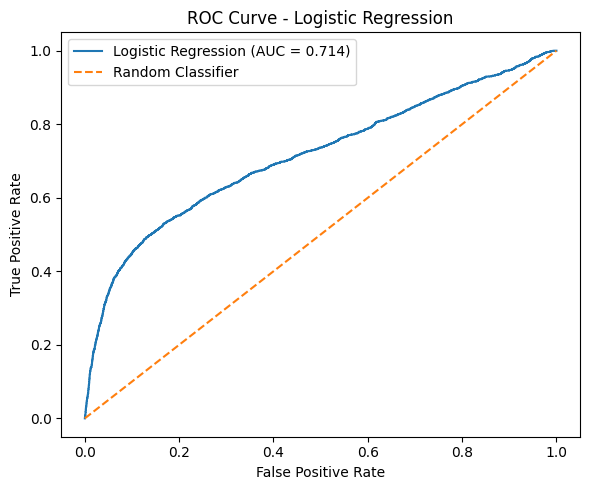

In [51]:
# =========================
# 3.11 ROC Curve — Logistic Regression Baseline
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_test_pd)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

The ROC curve shows the model's ability to distinguish between default and non-default clients across different thresholds. ROC-AUC measures how well the model ranks risky clients above less risky clients.

### Interpretation of Logistic Regression Coefficients

The Logistic Regression coefficient table shows the variables that are actually used by the model after preprocessing. Some feature names are different from the original dataset column names because the data has passed through the preprocessing pipeline.

For numeric variables, the prefix `num__` indicates that the variable has passed through the numeric preprocessing pipeline, including missing value imputation and standardization. For example, `LIMIT_BAL` becomes `num__LIMIT_BAL`, and `PAY_0` becomes `num__PAY_0`.

For categorical variables, the prefix `cat__` indicates that the variable has passed through one-hot encoding. For example, the original variable `EDUCATION` is transformed into dummy variables such as `cat__EDUCATION_2`, `cat__EDUCATION_3`, and `cat__EDUCATION_4`.

Conceptually, the Logistic Regression model calculates a risk score as a weighted combination of the selected credit risk features:

$$
risk\_score =
\beta_0
+ \beta_1 LIMIT\_BAL
+ \beta_2 AGE
+ \beta_3 PAY\_0
+ \beta_4 avg\_pay\_status
+ \beta_5 avg\_bill\_amt
+ \beta_6 avg\_pay\_amt
+ \beta_7 credit\_utilization
+ \beta_8 payment\_to\_bill\_ratio
+ \gamma D
$$

where \(D\) represents demographic dummy variables created from `SEX`, `EDUCATION`, and `MARRIAGE` after one-hot encoding.

The risk score is then converted into Probability of Default using the logistic function:

$$
PD = \frac{1}{1 + e^{-risk\_score}}
$$

A positive coefficient increases the risk score and therefore increases the predicted Probability of Default. A negative coefficient decreases the risk score and therefore lowers the predicted Probability of Default.

Since this project focuses on predictive credit risk modeling rather than statistical hypothesis testing, p-values are not reported. Model performance is evaluated using out-of-sample metrics such as ROC-AUC, Gini, precision, recall, F1-score, and threshold analysis.

In [52]:
# =========================
# 3.12 Logistic Regression Coefficients
# =========================

feature_names = log_reg_model.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": log_reg_model.named_steps["model"].coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,abs_coefficient
11,cat__EDUCATION_4,-1.1466,1.1466
2,num__PAY_0,0.6170,0.6170
3,num__avg_pay_status,0.3098,0.3098
5,num__avg_pay_amt,-0.2434,0.2434
12,cat__MARRIAGE_2,-0.1964,0.1964
0,num__LIMIT_BAL,-0.1763,0.1763
10,cat__EDUCATION_3,-0.1522,0.1522
9,cat__EDUCATION_2,-0.1151,0.1151
8,cat__SEX_2,-0.1119,0.1119
6,num__credit_utilization,-0.1009,0.1009


## 4. Model Comparison

The Logistic Regression model is used as an interpretable baseline. To evaluate whether more flexible machine learning models can improve default prediction, this section compares Logistic Regression with tree-based models.

The candidate models include Random Forest, XGBoost, and LightGBM. These models are suitable for tabular credit risk data because they can capture nonlinear relationships and interactions between repayment behavior, credit usage, and customer characteristics.

Models are compared using ROC-AUC, Gini, precision, recall, and F1-score for the default class.

In [53]:
# =========================
# 4.1 Import Model Comparison Libraries
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Try importing XGBoost and LightGBM safely

try:
    from xgboost import XGBClassifier
    xgboost_available = True
    print("XGBoost is available.")
except Exception as e:
    xgboost_available = False
    print("XGBoost is not available.")
    print("Reason:", type(e).__name__)

try:
    from lightgbm import LGBMClassifier
    lightgbm_available = True
    print("LightGBM is available.")
except Exception as e:
    lightgbm_available = False
    print("LightGBM is not available.")
    print("Reason:", type(e).__name__)

XGBoost is available.
LightGBM is available.


In [54]:
# =========================
# 4.2 Define Candidate Models
# =========================

# Calculate imbalance ratio from model training data for XGBoost
negative_count = (y_model_train == 0).sum()
positive_count = (y_model_train == 1).sum()

scale_pos_weight_value = negative_count / positive_count

print("Non-default count:", negative_count)
print("Default count:", positive_count)
print("Scale_pos_weight:", round(scale_pos_weight_value, 4))

candidate_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )
}

if xgboost_available:
    candidate_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight_value
    )

if lightgbm_available:
    candidate_models["LightGBM"] = LGBMClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )

candidate_models.keys()

Non-default count: 12266
Default count: 3484
Scale_pos_weight: 3.5207


dict_keys(['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'])

In [55]:
# =========================
# 4.3 Train and Evaluate Candidate Models
# =========================

model_results = []
model_predictions = {}

for model_name, model in candidate_models.items():
    
    print(f"Training {model_name}...")
    
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    # Train only on model training set
    model_pipeline.fit(X_model_train, y_model_train)
    
    # Evaluate on untouched test set
    y_pred = model_pipeline.predict(X_test)
    y_pd = model_pipeline.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_pd)
    gini = 2 * auc - 1

    model_results.append({
        "model": model_name,
        "accuracy": accuracy,
        "precision_default": precision,
        "recall_default": recall,
        "f1_default": f1,
        "roc_auc": auc,
        "gini": gini
    })
    
    model_predictions[model_name] = {
        "pipeline": model_pipeline,
        "y_pred": y_pred,
        "y_pd": y_pd
    }

model_comparison = pd.DataFrame(model_results)

model_comparison

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...


,model,accuracy,precision_default,recall_default,f1_default,roc_auc,gini
0,Logistic Regression,0.6740,0.3642,0.6354,0.4630,0.7153,0.4307
1,Random Forest,0.7636,0.4735,0.6148,0.5350,0.7776,0.5551
2,XGBoost,0.7583,0.4656,0.6258,0.5340,0.7765,0.5531
3,LightGBM,0.7564,0.4631,0.6328,0.5348,0.7765,0.5531


In [56]:
# =========================
# 4.3b Cross-Validation Verification (Stratified K-Fold)
# =========================

# Cross-validation confirms that train/test results are not due to a
# lucky random split. We run 5-fold CV on the training set only,
# so the test set remains untouched as a final holdout.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for model_name, model in candidate_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(pipe, X_model_train, y_model_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results.append({
        "model": model_name,
        "cv_auc_mean": scores.mean(),
        "cv_auc_std": scores.std()
    })
    print(f"{model_name}: CV AUC = {scores.mean():.4f} ± {scores.std():.4f}")

cv_comparison = pd.DataFrame(cv_results).sort_values("cv_auc_mean", ascending=False)
cv_comparison

Logistic Regression: CV AUC = 0.7217 ± 0.0054
Random Forest: CV AUC = 0.7780 ± 0.0052
XGBoost: CV AUC = 0.7774 ± 0.0057
LightGBM: CV AUC = 0.7768 ± 0.0046


,model,cv_auc_mean,cv_auc_std
1,Random Forest,0.7780,0.0052
2,XGBoost,0.7774,0.0057
3,LightGBM,0.7768,0.0046
0,Logistic Regression,0.7217,0.0054


In [57]:
# =========================
# 4.4 Sort Models by ROC-AUC
# =========================

model_comparison = model_comparison.sort_values(
    "roc_auc",
    ascending=False
).reset_index(drop=True)

model_comparison

,model,accuracy,precision_default,recall_default,f1_default,roc_auc,gini
0,Random Forest,0.7636,0.4735,0.6148,0.5350,0.7776,0.5551
1,XGBoost,0.7583,0.4656,0.6258,0.5340,0.7765,0.5531
2,LightGBM,0.7564,0.4631,0.6328,0.5348,0.7765,0.5531
3,Logistic Regression,0.6740,0.3642,0.6354,0.4630,0.7153,0.4307


Models are sorted by ROC-AUC because credit risk models are often evaluated by their ability to rank risky borrowers above less risky borrowers. A higher ROC-AUC indicates better discriminatory power.

ROC-AUC and Gini compare the discriminatory power of each model. A higher value means the model is better at ranking actual default clients as riskier than non-default clients.

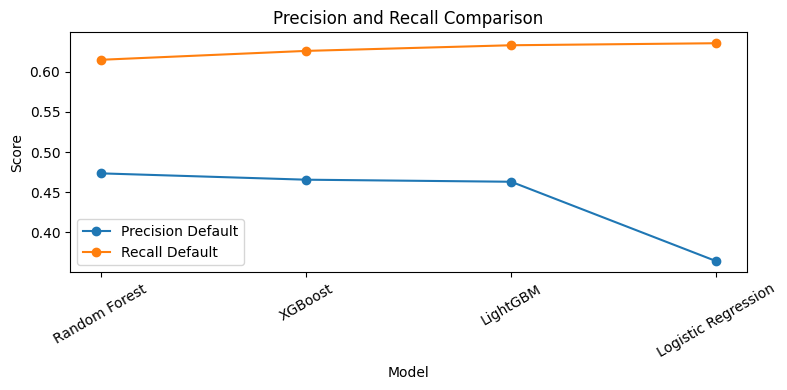

In [58]:
# =========================
# 4.5 Precision and Recall Comparison
# =========================

plt.figure(figsize=(8, 4))

plt.plot(
    model_comparison["model"],
    model_comparison["precision_default"],
    marker="o",
    label="Precision Default"
)

plt.plot(
    model_comparison["model"],
    model_comparison["recall_default"],
    marker="o",
    label="Recall Default"
)

plt.title("Precision and Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

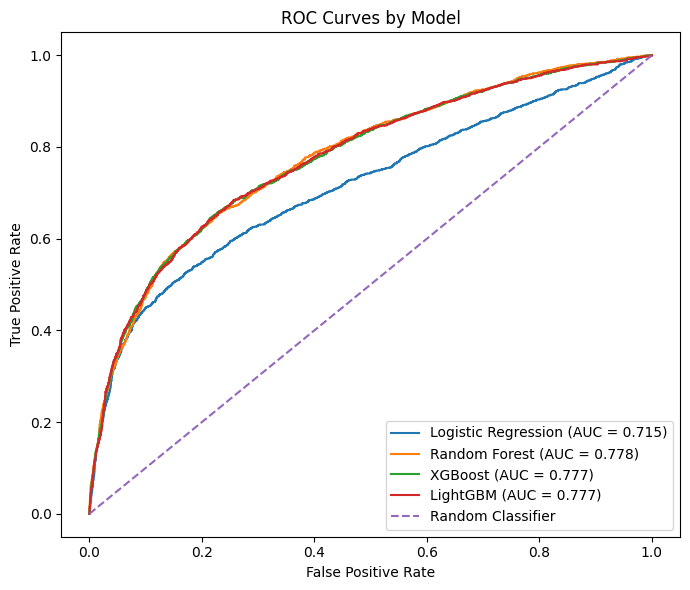

In [59]:
# =========================
# 4.6 ROC Curves for Candidate Models
# =========================

plt.figure(figsize=(7, 6))

for model_name in model_predictions.keys():
    y_pd = model_predictions[model_name]["y_pd"]
    fpr, tpr, thresholds = roc_curve(y_test, y_pd)
    auc_score = roc_auc_score(y_test, y_pd)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curves by Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.tight_layout()
plt.show()

The ROC curves show the trade-off between true positive rate and false positive rate across different thresholds. Models with curves closer to the top-left corner have stronger discriminatory power.

The final model is selected based primarily on ROC-AUC because the main objective of the PD model is to rank borrowers by default risk. Precision and recall are also reviewed to understand the classification trade-off.

### Probability Calibration with Platt Scaling

The final selected model is calibrated using Platt Scaling to improve the reliability of predicted Probability of Default.

The original model was trained with class imbalance adjustment, which improves default detection but may overestimate predicted PD. Calibration adjusts the predicted probabilities so that they are closer to observed default rates.

A separate calibration set is used to avoid calibrating the model on the same data used for model fitting.

In [60]:
# =========================
# 4.7 Select Final Model
# =========================

# Sort models by ROC-AUC
model_comparison_sorted = model_comparison.sort_values(
    "roc_auc",
    ascending=False
).reset_index(drop=True)

display(model_comparison_sorted)

# Best model by ROC-AUC
best_model_name = model_comparison_sorted.loc[0, "model"]
best_auc = model_comparison_sorted.loc[0, "roc_auc"]

# Logistic Regression benchmark
lr_auc = model_comparison.loc[
    model_comparison["model"] == "Logistic Regression",
    "roc_auc"
].values[0]

# Selection rule:
# If the best model improves ROC-AUC meaningfully over Logistic Regression,
# choose the best model. Otherwise, keep Logistic Regression for interpretability.
auc_improvement_threshold = 0.01

if best_auc - lr_auc < auc_improvement_threshold:
    final_model_name = "Logistic Regression"
    print(
        "Logistic Regression is selected because its performance is close to "
        "the best model and it is more interpretable."
    )
else:
    final_model_name = best_model_name
    print(
        f"{final_model_name} is selected because it improves ROC-AUC "
        "meaningfully compared with Logistic Regression."
    )

print("\nBest model by ROC-AUC:", best_model_name)
print("Best ROC-AUC:", round(best_auc, 4))
print("Logistic Regression ROC-AUC:", round(lr_auc, 4))
print("AUC improvement over Logistic Regression:", round(best_auc - lr_auc, 4))

# Retrieve final uncalibrated model and predictions
final_model = model_predictions[final_model_name]["pipeline"]

final_y_test_pred_uncalibrated = model_predictions[final_model_name]["y_pred"]
final_y_test_pd_uncalibrated = model_predictions[final_model_name]["y_pd"]

print("\nFinal model selected:", final_model_name)
print("Uncalibrated final model retrieved successfully.")
print("Average uncalibrated PD:", round(final_y_test_pd_uncalibrated.mean(), 4))
print("Actual default rate:", round(y_test.mean(), 4))

,model,accuracy,precision_default,recall_default,f1_default,roc_auc,gini
0,Random Forest,0.7636,0.4735,0.6148,0.5350,0.7776,0.5551
1,XGBoost,0.7583,0.4656,0.6258,0.5340,0.7765,0.5531
2,LightGBM,0.7564,0.4631,0.6328,0.5348,0.7765,0.5531
3,Logistic Regression,0.6740,0.3642,0.6354,0.4630,0.7153,0.4307


Random Forest is selected because it improves ROC-AUC meaningfully compared with Logistic Regression.

Best model by ROC-AUC: Random Forest
Best ROC-AUC: 0.7776
Logistic Regression ROC-AUC: 0.7153
AUC improvement over Logistic Regression: 0.0622

Final model selected: Random Forest
Uncalibrated final model retrieved successfully.
Average uncalibrated PD: 0.4231
Actual default rate: 0.2212


In [61]:
# =========================
# 4.8 Probability Calibration with Platt Scaling
# =========================

# Extract fitted preprocessor and fitted base model from final pipeline
final_preprocessor = final_model.named_steps["preprocessor"]
final_base_model = final_model.named_steps["model"]

# Transform calibration and test data using the fitted preprocessor
X_calib_transformed = final_preprocessor.transform(X_calib)
X_test_transformed_for_calibration = final_preprocessor.transform(X_test)

# Convert sparse matrix to dense array if needed
if hasattr(X_calib_transformed, "toarray"):
    X_calib_transformed = X_calib_transformed.toarray()

if hasattr(X_test_transformed_for_calibration, "toarray"):
    X_test_transformed_for_calibration = X_test_transformed_for_calibration.toarray()

# Create Platt Scaling calibrator
# Newer scikit-learn versions use FrozenEstimator for already-fitted models.
# Older versions use cv="prefit".
if frozen_estimator_available:
    calibrated_model = CalibratedClassifierCV(
        FrozenEstimator(final_base_model),
        method="sigmoid"
    )
else:
    calibrated_model = CalibratedClassifierCV(
        final_base_model,
        method="sigmoid",
        cv="prefit"
    )

# Fit calibrator on calibration set only
calibrated_model.fit(X_calib_transformed, y_calib)

# Get calibrated PD on test set
final_y_test_pd = calibrated_model.predict_proba(
    X_test_transformed_for_calibration
)[:, 1]

# Convert calibrated PD into class prediction at 0.5 threshold
final_y_test_pred = (final_y_test_pd >= 0.5).astype(int)

print("Probability calibration completed using Platt Scaling.")
print("Final model:", final_model_name)
print("Average uncalibrated PD:", round(final_y_test_pd_uncalibrated.mean(), 4))
print("Average calibrated PD  :", round(final_y_test_pd.mean(), 4))
print("Actual default rate    :", round(y_test.mean(), 4))

Probability calibration completed using Platt Scaling.
Final model: Random Forest
Average uncalibrated PD: 0.4231
Average calibrated PD  : 0.2208
Actual default rate    : 0.2212


In [62]:
# =========================
# 4.8b Calibration Comparison
# =========================

calibration_comparison = pd.DataFrame({
    "Metric": [
        "Average PD",
        "Actual Default Rate",
        "Brier Score",
        "Log Loss",
        "ROC-AUC",
        "Gini"
    ],
    "Uncalibrated": [
        final_y_test_pd_uncalibrated.mean(),
        y_test.mean(),
        brier_score_loss(y_test, final_y_test_pd_uncalibrated),
        log_loss(y_test, final_y_test_pd_uncalibrated),
        roc_auc_score(y_test, final_y_test_pd_uncalibrated),
        2 * roc_auc_score(y_test, final_y_test_pd_uncalibrated) - 1
    ],
    "Calibrated": [
        final_y_test_pd.mean(),
        y_test.mean(),
        brier_score_loss(y_test, final_y_test_pd),
        log_loss(y_test, final_y_test_pd),
        roc_auc_score(y_test, final_y_test_pd),
        2 * roc_auc_score(y_test, final_y_test_pd) - 1
    ]
})

calibration_comparison

,Metric,Uncalibrated,Calibrated
0,Average PD,0.4231,0.2208
1,Actual Default Rate,0.2212,0.2212
2,Brier Score,0.1788,0.1365
3,Log Loss,0.5428,0.4335
4,ROC-AUC,0.7776,0.7776
5,Gini,0.5551,0.5551


In [63]:
# =========================
# 4.9 Final Model Metrics
# =========================

final_auc = roc_auc_score(y_test, final_y_test_pd)
final_gini = 2 * final_auc - 1
final_accuracy = accuracy_score(y_test, final_y_test_pred)
final_precision = precision_score(y_test, final_y_test_pred, zero_division=0)
final_recall = recall_score(y_test, final_y_test_pred, zero_division=0)
final_f1 = f1_score(y_test, final_y_test_pred, zero_division=0)

final_model_metrics = pd.DataFrame({
    "Metric": [
        "Final Model",
        "PD Type",
        "Accuracy",
        "Precision Default",
        "Recall Default",
        "F1 Default",
        "ROC-AUC",
        "Gini"
    ],
    "Value": [
        final_model_name,
        "Calibrated PD - Platt Scaling",
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc,
        final_gini
    ]
})

final_model_metrics

,Metric,Value
0,Final Model,Random Forest
1,PD Type,Calibrated PD - Platt Scaling
2,Accuracy,0.8123
3,Precision Default,0.6216
4,Recall Default,0.3877
5,F1 Default,0.4776
6,ROC-AUC,0.7776
7,Gini,0.5551


In [64]:
# =========================
# 4.10 Final Model Confusion Matrix
# =========================

final_conf_matrix = confusion_matrix(y_test, final_y_test_pred)

final_conf_matrix_df = pd.DataFrame(
    final_conf_matrix,
    index=["Actual Non-default", "Actual Default"],
    columns=["Predicted Non-default", "Predicted Default"]
)

final_conf_matrix_df

,Predicted Non-default,Predicted Default
Actual Non-default,6539,470
Actual Default,1219,772


The confusion matrix shows how the final model classifies default and non-default clients at the default 0.5 threshold. This threshold will be further analyzed in the next section.

,rank,feature,importance,importance_pct
0,1,PAY_0,0.3374,0.3374
1,2,avg_pay_status,0.2692,0.2692
2,3,avg_pay_amt,0.0919,0.0919
3,4,credit_utilization,0.0690,0.0690
4,5,LIMIT_BAL,0.0686,0.0686
5,6,avg_bill_amt,0.0609,0.0609
6,7,payment_to_bill_ratio,0.0608,0.0608
7,8,AGE,0.0224,0.0224
8,9,SEX_2,0.0059,0.0059
9,10,EDUCATION_2,0.0049,0.0049


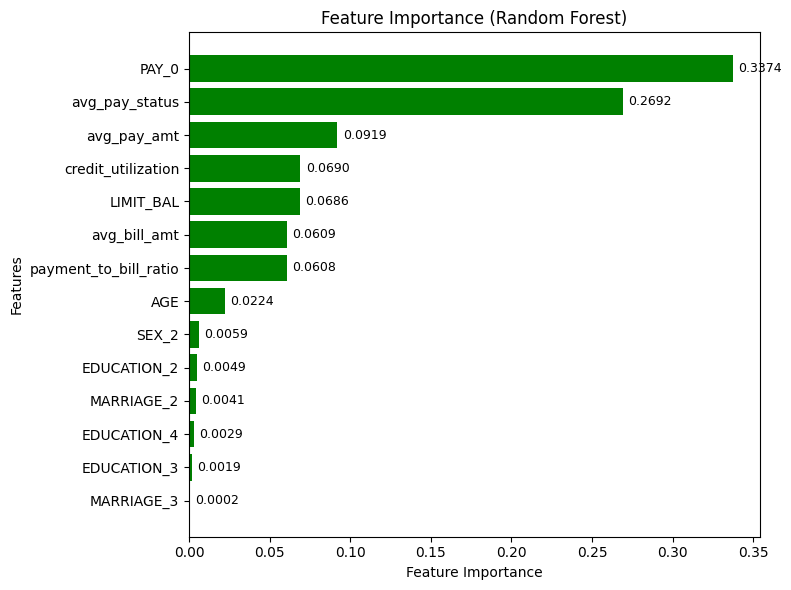

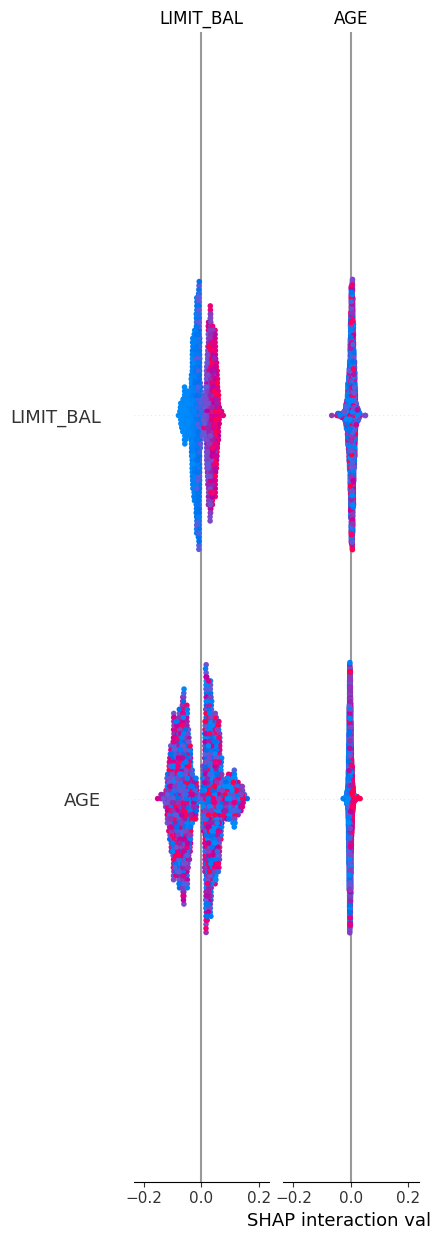

In [65]:
# =========================
# 4.11 Feature Importance + SHAP Analysis
# =========================

feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
model_object = final_model.named_steps["model"]
preprocessor_object = final_model.named_steps["preprocessor"]

X_test_transformed = preprocessor_object.transform(X_test)

# Convert sparse matrix to dense array if needed
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

clean_feature_names = (
    pd.Series(feature_names)
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

X_test_explain = pd.DataFrame(
    X_test_transformed,
    columns=clean_feature_names,
    index=X_test.index
)

# =========================
# Part A: Feature Importance
# =========================

if final_model_name != "Logistic Regression":

    if final_model_name == "XGBoost":
        booster = model_object.get_booster()
        importance_dict = booster.get_score(importance_type="weight")
        
        importance_rows = []
        
        for feature_id, importance_value in importance_dict.items():
            feature_index = int(feature_id.replace("f", ""))
            importance_rows.append({
                "feature": clean_feature_names.iloc[feature_index],
                "importance": importance_value
            })
            
        feature_importance = pd.DataFrame(importance_rows)

    else:
        feature_importance = pd.DataFrame({
            "feature": clean_feature_names,
            "importance": model_object.feature_importances_
        })

    feature_importance = (
        feature_importance
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    feature_importance["rank"] = feature_importance.index + 1
    feature_importance["importance_pct"] = (
        feature_importance["importance"] / feature_importance["importance"].sum()
    )

    feature_importance = feature_importance[
        ["rank", "feature", "importance", "importance_pct"]
    ]

    display(feature_importance.head(15))

    top_importance = feature_importance.head(15).sort_values("importance")

    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.barh(
        top_importance["feature"],
        top_importance["importance"],
        color="green",
        height=0.8
    )

    ax.set_title(f"Feature Importance ({final_model_name})")
    ax.set_xlabel("F score" if final_model_name == "XGBoost" else "Feature Importance")
    ax.set_ylabel("Features")

    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + max(top_importance["importance"]) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.0f}" if final_model_name == "XGBoost" else f"{width:.4f}",
            va="center",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

else:
    coef_df = pd.DataFrame({
        "feature": clean_feature_names,
        "coefficient": model_object.coef_[0]
    })

    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

    display(coef_df.head(15))


# =========================
# Part B: SHAP Summary Plot
# =========================

try:
    import shap

    X_test_shap_sample = X_test_explain.sample(
        n=min(2000, len(X_test_explain)),
        random_state=42
    )

    if final_model_name == "Logistic Regression":
        explainer = shap.LinearExplainer(model_object, X_test_shap_sample)
        shap_values = explainer.shap_values(X_test_shap_sample)
    else:
        explainer = shap.TreeExplainer(model_object)
        shap_values = explainer.shap_values(X_test_shap_sample)

        if isinstance(shap_values, list):
            shap_values = shap_values[1]

    shap.summary_plot(
        shap_values,
        X_test_shap_sample,
        max_display=15,
        show=True
    )

except ImportError:
    print("SHAP not installed. Run: pip install shap")

except Exception as e:
    print(f"SHAP skipped: {e}")

Feature importance helps identify which variables contribute most to the final model's predictions. For tree-based models, higher importance indicates that a feature is used more frequently or effectively to split borrowers by default risk.

In [66]:
# =========================
# 4.12 Add Final Model Predictions
# =========================

prediction_results["final_model"] = final_model_name
prediction_results["final_predicted_default"] = final_y_test_pred

prediction_results["final_predicted_PD_uncalibrated"] = final_y_test_pd_uncalibrated
prediction_results["final_predicted_PD"] = final_y_test_pd
prediction_results["pd_type"] = "Calibrated PD - Platt Scaling"

prediction_results.head()

,ID,actual_default,predicted_default,predicted_PD,final_model,final_predicted_default,final_predicted_PD_uncalibrated,final_predicted_PD,pd_type
0,8942,0,0,0.1844,Random Forest,0,0.2109,0.0631,Calibrated PD - Platt Scaling
1,17619,1,0,0.2156,Random Forest,0,0.5681,0.3179,Calibrated PD - Platt Scaling
2,27896,0,0,0.1420,Random Forest,0,0.2698,0.0848,Calibrated PD - Platt Scaling
3,16104,0,0,0.2969,Random Forest,1,0.7104,0.5019,Calibrated PD - Platt Scaling
4,4423,0,0,0.2353,Random Forest,0,0.2520,0.0776,Calibrated PD - Platt Scaling


The final model predictions are added to the prediction results. The `final_predicted_PD` column will be used in the next sections for threshold analysis, Expected Loss calculation, and risk segmentation.

## 5. Model Validation and Threshold Analysis

This section evaluates the final selected model in more detail. Since the final model produces a predicted Probability of Default (PD), different classification thresholds can be tested to understand the trade-off between precision and recall.

The default threshold of 0.5 may not be optimal for credit risk because missing actual default clients can lead to credit losses. Therefore, threshold analysis is used to compare different PD cutoffs and select an operating threshold for risk monitoring.

In [67]:
# =========================
# 5.1 Review Final Model Performance
# =========================

final_model_metrics


,Metric,Value
0,Final Model,Random Forest
1,PD Type,Calibrated PD - Platt Scaling
2,Accuracy,0.8123
3,Precision Default,0.6216
4,Recall Default,0.3877
5,F1 Default,0.4776
6,ROC-AUC,0.7776
7,Gini,0.5551


The final model metrics provide an overall view of model performance on the test set. Since the dataset is imbalanced, accuracy alone is not sufficient. Precision, recall, F1-score, ROC-AUC, and Gini are used to evaluate the model's ability to identify and rank default risk.

In [68]:
# =========================
# 5.2 Confusion Matrix at 0.5 Threshold
# =========================

conf_matrix_05 = confusion_matrix(y_test, final_y_test_pred)

conf_matrix_05_df = pd.DataFrame(
    conf_matrix_05,
    index=["Actual Non-default", "Actual Default"],
    columns=["Predicted Non-default", "Predicted Default"]
)

conf_matrix_05_df

,Predicted Non-default,Predicted Default
Actual Non-default,6539,470
Actual Default,1219,772


In [69]:
tn, fp, fn, tp = conf_matrix_05.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 6539
False Positives: 470
False Negatives: 1219
True Positives: 772


In [70]:
# =========================
# 5.3 Threshold Comparison - Final Model
# =========================

thresholds = [0.5, 0.4, 0.3, 0.2]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (final_y_test_pd >= threshold).astype(int)
    
    accuracy_t = accuracy_score(y_test, y_pred_threshold)
    precision_t = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall_t = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1_t = f1_score(y_test, y_pred_threshold, zero_division=0)
    
    conf_matrix_t = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = conf_matrix_t.ravel()
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_t,
        "precision": precision_t,
        "recall": recall_t,
        "f1_score": f1_t,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "predicted_default_count": y_pred_threshold.sum(),
        "predicted_default_rate": y_pred_threshold.mean()
    })

threshold_summary = pd.DataFrame(threshold_results)

threshold_summary

,threshold,accuracy,precision,recall,f1_score,true_negative,false_positive,false_negative,true_positive,predicted_default_count,predicted_default_rate
0,0.5000,0.8123,0.6216,0.3877,0.4776,6539,470,1219,772,1242,0.1380
1,0.4000,0.8073,0.5803,0.4666,0.5173,6337,672,1062,929,1601,0.1779
2,0.3000,0.7926,0.5297,0.5560,0.5425,6026,983,884,1107,2090,0.2322
3,0.2000,0.7332,0.4331,0.6670,0.5252,5271,1738,663,1328,3066,0.3407


Lowering the classification threshold usually increases recall because more clients are classified as potential defaults. However, this often reduces precision because more non-default clients may also be flagged as default. This trade-off is important in credit risk decision-making.

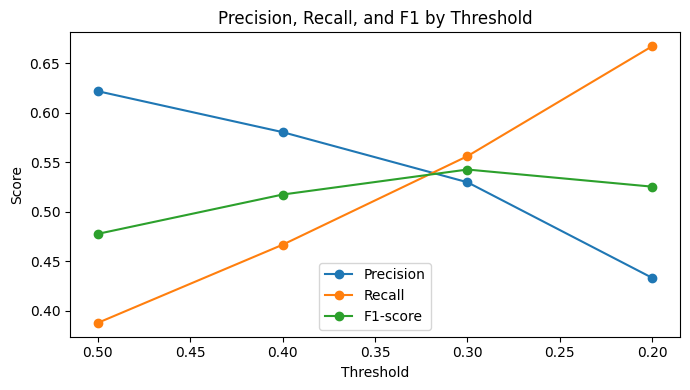

In [71]:
# =========================
# 5.4 Precision, Recall, and F1 by Threshold
# =========================

plt.figure(figsize=(7, 4))

plt.plot(threshold_summary["threshold"], threshold_summary["precision"], marker="o", label="Precision")
plt.plot(threshold_summary["threshold"], threshold_summary["recall"], marker="o", label="Recall")
plt.plot(threshold_summary["threshold"], threshold_summary["f1_score"], marker="o", label="F1-score")

plt.title("Precision, Recall, and F1 by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()

plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

The chart shows the trade-off between precision and recall. As the threshold decreases, recall typically increases because the model identifies more actual default clients. However, precision may decrease because more non-default clients are also classified as default.

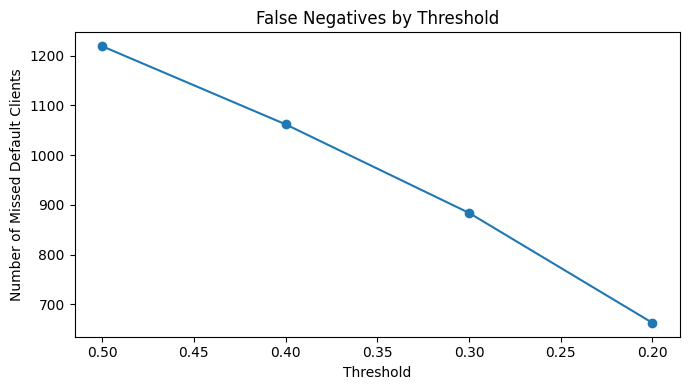

In [72]:
# =========================
# 5.5 False Negatives by Threshold
# =========================

plt.figure(figsize=(7, 4))

plt.plot(
    threshold_summary["threshold"],
    threshold_summary["false_negative"],
    marker="o"
)

plt.title("False Negatives by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Number of Missed Default Clients")

plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

False negatives represent actual default clients that the model fails to identify. In credit risk, reducing false negatives is important because missed default clients can lead to credit losses.

In [73]:
# =========================
# 5.6 Choose Operating Threshold
# =========================

selected_threshold = 0.3

y_test_pred_selected = (final_y_test_pd >= selected_threshold).astype(int)

selected_conf_matrix = confusion_matrix(y_test, y_test_pred_selected)

selected_conf_matrix_df = pd.DataFrame(
    selected_conf_matrix,
    index=["Actual Non-default", "Actual Default"],
    columns=["Predicted Non-default", "Predicted Default"]
)

selected_conf_matrix_df

,Predicted Non-default,Predicted Default
Actual Non-default,6026,983
Actual Default,884,1107


In [74]:
selected_accuracy = accuracy_score(y_test, y_test_pred_selected)
selected_precision = precision_score(y_test, y_test_pred_selected, zero_division=0)
selected_recall = recall_score(y_test, y_test_pred_selected, zero_division=0)
selected_f1 = f1_score(y_test, y_test_pred_selected, zero_division=0)

selected_threshold_metrics = pd.DataFrame({
    "Metric": [
        "Final Model",
        "Selected Threshold",
        "Accuracy",
        "Precision Default",
        "Recall Default",
        "F1 Default",
        "ROC-AUC",
        "Gini"
    ],
    "Value": [
        final_model_name,
        selected_threshold,
        selected_accuracy,
        selected_precision,
        selected_recall,
        selected_f1,
        final_auc,
        final_gini
    ]
})

selected_threshold_metrics

,Metric,Value
0,Final Model,Random Forest
1,Selected Threshold,0.3000
2,Accuracy,0.7926
3,Precision Default,0.5297
4,Recall Default,0.5560
5,F1 Default,0.5425
6,ROC-AUC,0.7776
7,Gini,0.5551


A lower threshold is selected to improve recall and reduce the number of missed default clients. This threshold may be more suitable for credit risk monitoring, where identifying risky clients is often more important than maximizing overall accuracy.

In [75]:
# =========================
# 5.7 Add Selected Threshold Prediction
# =========================

prediction_results["predicted_default_selected_threshold"] = y_test_pred_selected
prediction_results["selected_threshold"] = selected_threshold

prediction_results.head()

,ID,actual_default,predicted_default,predicted_PD,final_model,final_predicted_default,final_predicted_PD_uncalibrated,final_predicted_PD,pd_type,predicted_default_selected_threshold,selected_threshold
0,8942,0,0,0.1844,Random Forest,0,0.2109,0.0631,Calibrated PD - Platt Scaling,0,0.3000
1,17619,1,0,0.2156,Random Forest,0,0.5681,0.3179,Calibrated PD - Platt Scaling,1,0.3000
2,27896,0,0,0.1420,Random Forest,0,0.2698,0.0848,Calibrated PD - Platt Scaling,0,0.3000
3,16104,0,0,0.2969,Random Forest,1,0.7104,0.5019,Calibrated PD - Platt Scaling,1,0.3000
4,4423,0,0,0.2353,Random Forest,0,0.2520,0.0776,Calibrated PD - Platt Scaling,0,0.3000


The selected threshold prediction is added to the prediction results. This allows the model output to be used in later Expected Loss calculation and risk segmentation.

## 6. Expected Loss and Risk Segmentation

This section translates the predicted Probability of Default (PD) into Expected Loss using a simplified credit risk framework.

Expected Loss is calculated as:

\[
Expected\ Loss = PD \times LGD \times EAD
\]

where:

- `PD` is the predicted Probability of Default from the final selected model.
- `LGD` is the assumed Loss Given Default.
- `EAD` is the Exposure at Default.

In this project, `BILL_AMT1` is used as a proxy for EAD because it represents the most recent bill statement amount available before the next-month default outcome. This is a closer approximation of current outstanding exposure than `LIMIT_BAL`, which represents the approved credit limit rather than the amount currently owed.

Negative bill amounts are clipped to zero because exposure should not be negative.

LGD is assumed to be 45% due to the absence of recovery, collateral, and workout data in the dataset. Therefore, LGD is not estimated from the data and should be interpreted as a simplifying assumption for educational portfolio risk analysis.

The resulting Expected Loss is then used together with predicted PD to create borrower-level risk segments.

In [76]:
# =========================
# 6.1 Create Scored Test Portfolio
# =========================

scored_portfolio = X_test.copy()

scored_portfolio.insert(
    0,
    "ID",
    df_model.loc[X_test.index, "ID"].values
)

scored_portfolio["actual_default"] = y_test.values
scored_portfolio["predicted_PD"] = final_y_test_pd
scored_portfolio["predicted_default_05"] = final_y_test_pred
scored_portfolio["predicted_default_selected_threshold"] = y_test_pred_selected

scored_portfolio.head()

,ID,LIMIT_BAL,AGE,SEX,EDUCATION,MARRIAGE,PAY_0,avg_pay_status,avg_bill_amt,avg_pay_amt,credit_utilization,payment_to_bill_ratio,actual_default,predicted_PD,predicted_default_05,predicted_default_selected_threshold
8941,8942,230000,30,1,2,2,0,0.0000,"69,871.6667","2,804.8333",0.3038,0.0401,0,0.0631,0,0
17618,17619,80000,32,2,1,1,-1,0.5000,"4,024.3333",807.3333,0.0503,0.2006,1,0.3179,0,1
27895,27896,100000,29,2,1,2,0,0.0000,"83,106.0000","16,288.1667",0.8311,0.1960,0,0.0848,0,0
16103,16104,10000,37,2,2,1,-1,2.0000,"2,664.6667",156.0000,0.2665,0.0585,0,0.5019,1,1
4422,4423,110000,34,2,2,1,0,0.0000,"29,096.0000","2,816.6667",0.2645,0.0968,0,0.0776,0,0


A scored test portfolio is created by combining the original borrower features with the model outputs. Each borrower now has an actual default label, predicted Probability of Default, and predicted default classification.

In [77]:
# =========================
# 6.2 Define LGD and EAD
# =========================

LGD_ASSUMPTION = 0.45

# Assign LGD assumption
scored_portfolio["LGD"] = LGD_ASSUMPTION

# Use the latest bill statement amount as proxy for EAD.
# BILL_AMT1 is taken from the original df because it was excluded from the modeling feature set.
# Negative balances are clipped to zero because exposure should not be negative.
scored_portfolio["EAD"] = (
    df.loc[X_test.index, "BILL_AMT1"]
    .clip(lower=0)
    .values
)

# Keep credit limit for comparison and dashboard reference
scored_portfolio["credit_limit"] = df.loc[X_test.index, "LIMIT_BAL"].values

scored_portfolio[
    [
        "ID",
        "predicted_PD",
        "LGD",
        "EAD",
        "credit_limit"
    ]
].head()

,ID,predicted_PD,LGD,EAD,credit_limit
8941,8942,0.0631,0.4500,101832,230000
17618,17619,0.3179,0.4500,4927,80000
27895,27896,0.0848,0.4500,167410,100000
16103,16104,0.5019,0.4500,3305,10000
4422,4423,0.0776,0.4500,24147,110000


Because the dataset does not contain recovery, collateral, or workout information, LGD is assumed to be 45%. This value is not estimated from the dataset and should be treated as a simplifying assumption.

`BILL_AMT1` is used as the proxy for EAD because it represents the most recent bill statement amount before the next-month default outcome. This is closer to current outstanding exposure than `LIMIT_BAL`, which represents the approved credit limit rather than the amount actually owed.

In [78]:
# =========================
# 6.3 Calculate Expected Loss
# =========================

scored_portfolio["expected_loss"] = (
    scored_portfolio["predicted_PD"]
    * scored_portfolio["LGD"]
    * scored_portfolio["EAD"]
)

scored_portfolio[
    [
        "ID",
        "predicted_PD",
        "LGD",
        "EAD",
        "expected_loss"
    ]
].head()

,ID,predicted_PD,LGD,EAD,expected_loss
8941,8942,0.0631,0.4500,101832,"2,890.5934"
17618,17619,0.3179,0.4500,4927,704.8500
27895,27896,0.0848,0.4500,167410,"6,385.2218"
16103,16104,0.5019,0.4500,3305,746.5068
4422,4423,0.0776,0.4500,24147,842.9828


In [79]:
# =========================
# 6.3b Sensitivity Check: EAD Using Credit Limit
# =========================

scored_portfolio["EAD_limit_proxy"] = scored_portfolio["credit_limit"]

scored_portfolio["expected_loss_limit_proxy"] = (
    scored_portfolio["predicted_PD"]
    * scored_portfolio["LGD"]
    * scored_portfolio["EAD_limit_proxy"]
)

ead_proxy_comparison = pd.DataFrame({
    "EAD Proxy": ["BILL_AMT1", "LIMIT_BAL"],
    "Total EAD": [
        scored_portfolio["EAD"].sum(),
        scored_portfolio["EAD_limit_proxy"].sum()
    ],
    "Average EAD": [
        scored_portfolio["EAD"].mean(),
        scored_portfolio["EAD_limit_proxy"].mean()
    ],
    "Total Expected Loss": [
        scored_portfolio["expected_loss"].sum(),
        scored_portfolio["expected_loss_limit_proxy"].sum()
    ],
    "Average Expected Loss": [
        scored_portfolio["expected_loss"].mean(),
        scored_portfolio["expected_loss_limit_proxy"].mean()
    ]
})

ead_proxy_comparison

,EAD Proxy,Total EAD,Average EAD,Total Expected Loss,Average Expected Loss
0,BILL_AMT1,461734776,"51,303.8640","41,527,583.8697","4,614.1760"
1,LIMIT_BAL,1507047680,"167,449.7422","114,355,403.1522","12,706.1559"


Expected Loss combines default probability, loss severity, and exposure size. A borrower with high PD may not always generate the highest expected loss if the exposure is small. Similarly, a borrower with moderate PD but large exposure can generate a high expected loss.

In [80]:
# =========================
# 6.4 Create PD Risk Bands
# =========================

def assign_pd_risk_band(pd_value):
    if pd_value < 0.10:
        return "Low Risk"
    elif pd_value < 0.30:
        return "Medium Risk"
    else:
        return "High Risk"

scored_portfolio["pd_risk_band"] = scored_portfolio["predicted_PD"].apply(assign_pd_risk_band)

scored_portfolio[
    [
        "ID",
        "predicted_PD",
        "pd_risk_band",
        "expected_loss"
    ]
].head()

,ID,predicted_PD,pd_risk_band,expected_loss
8941,8942,0.0631,Low Risk,"2,890.5934"
17618,17619,0.3179,High Risk,704.8500
27895,27896,0.0848,Low Risk,"6,385.2218"
16103,16104,0.5019,High Risk,746.5068
4422,4423,0.0776,Low Risk,842.9828


Borrowers are grouped into PD-based risk bands. These segments help translate continuous PD estimates into simpler risk categories for monitoring and reporting.

In [81]:
# =========================
# 6.5 Create Expected Loss Risk Bands
# =========================

el_75 = scored_portfolio["expected_loss"].quantile(0.75)
el_90 = scored_portfolio["expected_loss"].quantile(0.90)

def assign_el_risk_band(expected_loss):
    if expected_loss < el_75:
        return "Low/Medium EL"
    elif expected_loss < el_90:
        return "High EL"
    else:
        return "Very High EL"

scored_portfolio["el_risk_band"] = scored_portfolio["expected_loss"].apply(assign_el_risk_band)

scored_portfolio[
    [
        "ID",
        "predicted_PD",
        "EAD",
        "expected_loss",
        "pd_risk_band",
        "el_risk_band"
    ]
].head()

,ID,predicted_PD,EAD,expected_loss,pd_risk_band,el_risk_band
8941,8942,0.0631,101832,"2,890.5934",Low Risk,Low/Medium EL
17618,17619,0.3179,4927,704.8500,High Risk,Low/Medium EL
27895,27896,0.0848,167410,"6,385.2218",Low Risk,High EL
16103,16104,0.5019,3305,746.5068,High Risk,Low/Medium EL
4422,4423,0.0776,24147,842.9828,Low Risk,Low/Medium EL


Expected Loss risk bands are created using portfolio-level percentiles. This helps identify borrowers who contribute the most to expected portfolio loss, even if their PD is not the highest.

In [82]:
# =========================
# 6.6 Portfolio-Level Expected Loss Summary
# =========================

portfolio_summary = pd.DataFrame({
    "total_customers": [len(scored_portfolio)],
    "total_EAD": [scored_portfolio["EAD"].sum()],
    "average_PD": [scored_portfolio["predicted_PD"].mean()],
    "average_LGD": [scored_portfolio["LGD"].mean()],
    "total_expected_loss": [scored_portfolio["expected_loss"].sum()],
    "average_expected_loss": [scored_portfolio["expected_loss"].mean()],
    "actual_default_rate": [scored_portfolio["actual_default"].mean()]
})

portfolio_summary

,total_customers,total_EAD,average_PD,average_LGD,total_expected_loss,average_expected_loss,actual_default_rate
0,9000,461734776,0.2208,0.4500,"41,527,583.8697","4,614.1760",0.2212


The portfolio-level summary provides an aggregated view of total exposure, average PD, total expected loss, and actual default rate. This connects borrower-level model predictions with portfolio-level credit risk reporting.

In [83]:
# =========================
# 6.7 Summary by PD Risk Band
# =========================

pd_risk_summary = (
    scored_portfolio
    .groupby("pd_risk_band")
    .agg(
        customer_count=("ID", "count"),
        total_EAD=("EAD", "sum"),
        average_PD=("predicted_PD", "mean"),
        actual_default_rate=("actual_default", "mean"),
        total_expected_loss=("expected_loss", "sum"),
        average_expected_loss=("expected_loss", "mean")
    )
    .reset_index()
)

pd_risk_summary

,pd_risk_band,customer_count,total_EAD,average_PD,actual_default_rate,total_expected_loss,average_expected_loss
0,High Risk,2090,94878593,0.5408,0.5297,"25,014,155.6435","11,968.4955"
1,Low Risk,3013,234989193,0.0727,0.0783,"7,499,533.9860","2,489.0587"
2,Medium Risk,3897,131866990,0.1636,0.1663,"9,013,894.2402","2,313.0342"


The PD risk band summary shows how customers, exposure, observed default rate, and expected loss are distributed across risk segments.

In [84]:
# =========================
# 6.8 Sort PD Risk Bands
# =========================

risk_band_order = ["Low Risk", "Medium Risk", "High Risk"]

pd_risk_summary["pd_risk_band"] = pd.Categorical(
    pd_risk_summary["pd_risk_band"],
    categories=risk_band_order,
    ordered=True
)

pd_risk_summary = pd_risk_summary.sort_values("pd_risk_band")

pd_risk_summary

,pd_risk_band,customer_count,total_EAD,average_PD,actual_default_rate,total_expected_loss,average_expected_loss
1,Low Risk,3013,234989193,0.0727,0.0783,"7,499,533.9860","2,489.0587"
2,Medium Risk,3897,131866990,0.1636,0.1663,"9,013,894.2402","2,313.0342"
0,High Risk,2090,94878593,0.5408,0.5297,"25,014,155.6435","11,968.4955"


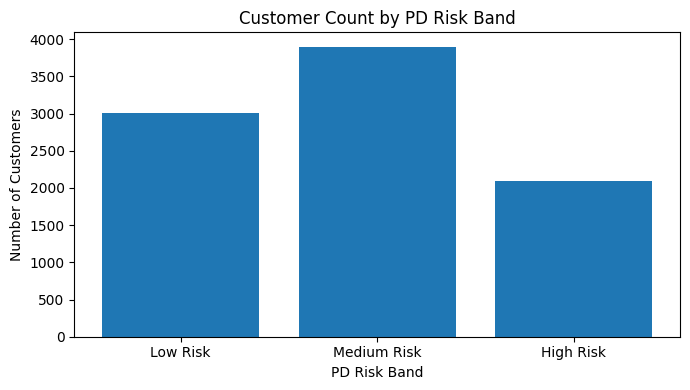

In [85]:
# =========================
# 6.9 Customer Count by PD Risk Band
# =========================

plt.figure(figsize=(7, 4))

plt.bar(
    pd_risk_summary["pd_risk_band"],
    pd_risk_summary["customer_count"]
)

plt.title("Customer Count by PD Risk Band")
plt.xlabel("PD Risk Band")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

This chart shows the number of customers in each PD risk band. It helps identify whether the portfolio is concentrated in low, medium, or high predicted risk groups.

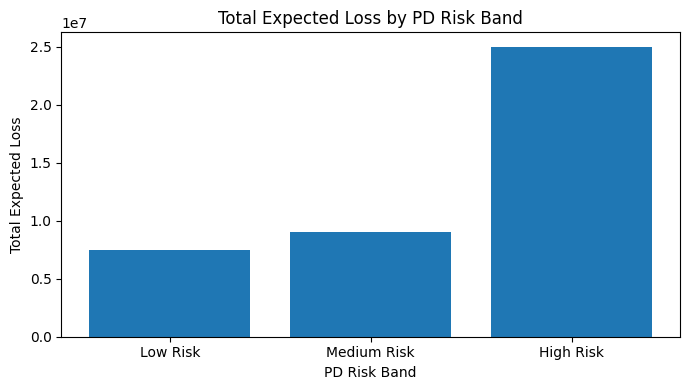

In [86]:
# =========================
# 6.10 Expected Loss by PD Risk Band
# =========================

plt.figure(figsize=(7, 4))

plt.bar(
    pd_risk_summary["pd_risk_band"],
    pd_risk_summary["total_expected_loss"]
)

plt.title("Total Expected Loss by PD Risk Band")
plt.xlabel("PD Risk Band")
plt.ylabel("Total Expected Loss")

plt.tight_layout()
plt.show()

In [87]:
# =========================
# 6.11 Top Borrowers by Expected Loss
# =========================

top_el_borrowers = (
    scored_portfolio[
        [
            "ID",
            "predicted_PD",
            "EAD",
            "LGD",
            "expected_loss",
            "pd_risk_band",
            "el_risk_band",
            "actual_default"
        ]
    ]
    .sort_values("expected_loss", ascending=False)
    .head(10)
)

top_el_borrowers

,ID,predicted_PD,EAD,LGD,expected_loss,pd_risk_band,el_risk_band,actual_default
10768,10769,0.5744,564757,0.4500,"145,986.0196",High Risk,Very High EL,1
19485,19486,0.6219,506515,0.4500,"141,761.2593",High Risk,Very High EL,1
27498,27499,0.5032,613860,0.4500,"138,989.2121",High Risk,Very High EL,1
15593,15594,0.5961,458652,0.4500,"123,038.8282",High Risk,Very High EL,1
4703,4704,0.6158,435924,0.4500,"120,806.8311",High Risk,Very High EL,1
19667,19668,0.6042,420522,0.4500,"114,337.7473",High Risk,Very High EL,0
27034,27035,0.5879,426429,0.4500,"112,822.8893",High Risk,Very High EL,1
15316,15317,0.5644,412289,0.4500,"104,721.0362",High Risk,Very High EL,1
14588,14589,0.7004,327918,0.4500,"103,350.7805",High Risk,Very High EL,0
1496,1497,0.6336,360023,0.4500,"102,654.3214",High Risk,Very High EL,1


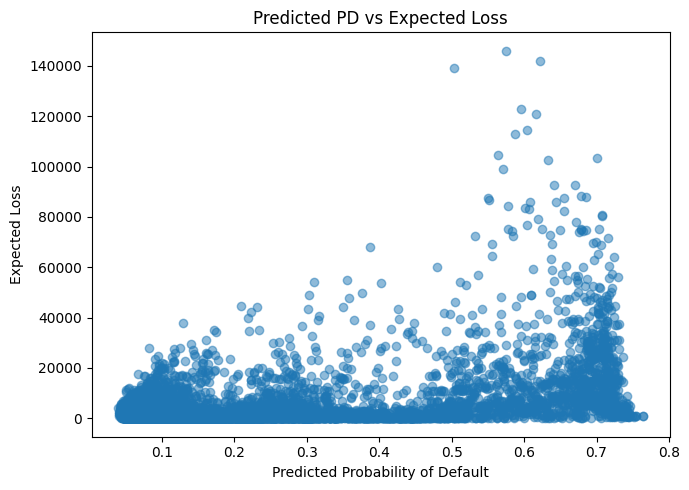

In [88]:
# =========================
# 6.12 PD vs Expected Loss
# =========================

plt.figure(figsize=(7, 5))

plt.scatter(
    scored_portfolio["predicted_PD"],
    scored_portfolio["expected_loss"],
    alpha=0.5
)

plt.title("Predicted PD vs Expected Loss")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Expected Loss")

plt.tight_layout()
plt.show()

In [89]:
# =========================
# 6.13 Expected Loss by Actual Default Status
# =========================

actual_default_el_summary = (
    scored_portfolio
    .groupby("actual_default")
    .agg(
        customer_count=("ID", "count"),
        average_PD=("predicted_PD", "mean"),
        average_EAD=("EAD", "mean"),
        total_expected_loss=("expected_loss", "sum"),
        average_expected_loss=("expected_loss", "mean")
    )
    .reset_index()
)

actual_default_el_summary

,actual_default,customer_count,average_PD,average_EAD,total_expected_loss,average_expected_loss
0,0,7009,0.1730,"51,596.6017","23,903,521.3159","3,410.4040"
1,1,1991,0.3889,"50,273.3275","17,624,062.5539","8,851.8647"


## 7 Scenario-Based Stress Testing

After calculating the base-case Expected Loss, a simple scenario-based stress test is performed to assess how portfolio losses may change under adverse credit conditions.

The stress test applies shocks to three key credit risk components:

- `PD`: calibrated Probability of Default from the final selected model
- `LGD`: assumed Loss Given Default
- `EAD`: Exposure at Default, proxied by `BILL_AMT1`

This is not a macroeconomic IFRS 9 stress model. Instead, it is a simplified sensitivity analysis designed to show how Expected Loss may increase if borrower credit quality deteriorates and recovery conditions worsen.

In [90]:
# =========================
# 7.1 Scenario-Based Stress Testing
# =========================

stress_scenarios = {
    "Base Case": {
        "pd_multiplier": 1.00,
        "lgd": 0.45,
        "ead_multiplier": 1.00
    },
    "Moderate Stress": {
        "pd_multiplier": 1.20,
        "lgd": 0.50,
        "ead_multiplier": 1.05
    },
    "Severe Stress": {
        "pd_multiplier": 1.50,
        "lgd": 0.60,
        "ead_multiplier": 1.10
    }
}

stress_results = []

for scenario_name, params in stress_scenarios.items():
    
    stressed_pd = (
        scored_portfolio["predicted_PD"] 
        * params["pd_multiplier"]
    ).clip(upper=1)
    
    stressed_lgd = params["lgd"]
    
    stressed_ead = (
        scored_portfolio["EAD"] 
        * params["ead_multiplier"]
    )
    
    stressed_expected_loss = (
        stressed_pd 
        * stressed_lgd 
        * stressed_ead
    )
    
    stress_results.append({
        "scenario": scenario_name,
        "pd_multiplier": params["pd_multiplier"],
        "lgd": stressed_lgd,
        "ead_multiplier": params["ead_multiplier"],
        "average_pd": stressed_pd.mean(),
        "total_ead": stressed_ead.sum(),
        "total_expected_loss": stressed_expected_loss.sum(),
        "average_expected_loss": stressed_expected_loss.mean()
    })

stress_test_summary = pd.DataFrame(stress_results)

base_el = stress_test_summary.loc[
    stress_test_summary["scenario"] == "Base Case",
    "total_expected_loss"
].values[0]

stress_test_summary["el_increase_vs_base"] = (
    stress_test_summary["total_expected_loss"] - base_el
)

stress_test_summary["el_increase_pct_vs_base"] = (
    stress_test_summary["el_increase_vs_base"] / base_el
)

stress_test_summary

,scenario,pd_multiplier,lgd,ead_multiplier,average_pd,total_ead,total_expected_loss,average_expected_loss,el_increase_vs_base,el_increase_pct_vs_base
0,Base Case,1.0000,0.4500,1.0000,0.2208,"461,734,776.0000","41,527,583.8697","4,614.1760",0.0000,0.0000
1,Moderate Stress,1.2000,0.5000,1.0500,0.2649,"484,821,514.8000","58,138,617.4176","6,459.8464","16,611,033.5479",0.4000
2,Severe Stress,1.5000,0.6000,1.1000,0.3273,"507,908,253.6000","90,181,065.1628","10,020.1184","48,653,481.2931",1.1716


The stress test shows how portfolio Expected Loss changes under progressively worse credit conditions.

Compared with the base case, the moderate and severe stress scenarios increase Expected Loss through three channels:

1. Higher PD, representing weaker borrower credit quality.
2. Higher LGD, representing lower recovery under stressed conditions.
3. Higher EAD, representing higher outstanding exposure.

The results should be interpreted as a sensitivity analysis rather than a formal macroeconomic stress test.

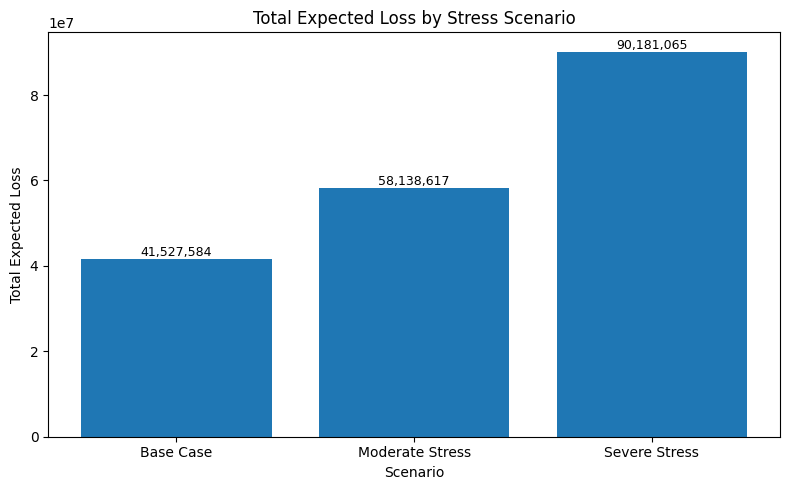

In [91]:
# =========================
# 7.2 Visualize Expected Loss by Stress Scenario
# =========================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    stress_test_summary["scenario"],
    stress_test_summary["total_expected_loss"]
)

plt.title("Total Expected Loss by Stress Scenario")
plt.xlabel("Scenario")
plt.ylabel("Total Expected Loss")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [92]:
# =========================
# 7.3 Stress Test by PD Risk Band
# =========================

stress_band_results = []

for scenario_name, params in stress_scenarios.items():
    
    temp = scored_portfolio.copy()
    
    temp["stress_scenario"] = scenario_name
    
    temp["stressed_PD"] = (
        temp["predicted_PD"] 
        * params["pd_multiplier"]
    ).clip(upper=1)
    
    temp["stressed_LGD"] = params["lgd"]
    
    temp["stressed_EAD"] = (
        temp["EAD"] 
        * params["ead_multiplier"]
    )
    
    temp["stressed_expected_loss"] = (
        temp["stressed_PD"]
        * temp["stressed_LGD"]
        * temp["stressed_EAD"]
    )
    
    band_summary = (
        temp.groupby("pd_risk_band", observed=False)
        .agg(
            customer_count=("ID", "count"),
            average_stressed_PD=("stressed_PD", "mean"),
            total_stressed_EAD=("stressed_EAD", "sum"),
            total_stressed_expected_loss=("stressed_expected_loss", "sum"),
            average_stressed_expected_loss=("stressed_expected_loss", "mean")
        )
        .reset_index()
    )
    
    band_summary["scenario"] = scenario_name
    
    stress_band_results.append(band_summary)

stress_band_summary = pd.concat(stress_band_results, ignore_index=True)

risk_band_order = ["Low Risk", "Medium Risk", "High Risk"]

stress_band_summary["pd_risk_band"] = pd.Categorical(
    stress_band_summary["pd_risk_band"],
    categories=risk_band_order,
    ordered=True
)

stress_band_summary = stress_band_summary.sort_values(
    ["scenario", "pd_risk_band"]
).reset_index(drop=True)

stress_band_summary

,pd_risk_band,customer_count,average_stressed_PD,total_stressed_EAD,total_stressed_expected_loss,average_stressed_expected_loss,scenario
0,Low Risk,3013,0.0727,"234,989,193.0000","7,499,533.9860","2,489.0587",Base Case
1,Medium Risk,3897,0.1636,"131,866,990.0000","9,013,894.2402","2,313.0342",Base Case
2,High Risk,2090,0.5408,"94,878,593.0000","25,014,155.6435","11,968.4955",Base Case
3,Low Risk,3013,0.0873,"246,738,652.6500","10,499,347.5804","3,484.6822",Moderate Stress
4,Medium Risk,3897,0.1963,"138,460,339.5000","12,619,451.9363","3,238.2479",Moderate Stress
5,High Risk,2090,0.6490,"99,622,522.6500","35,019,817.9009","16,755.8937",Moderate Stress
6,Low Risk,3013,0.1091,"258,488,112.3000","16,498,974.7693","5,475.9292",Severe Stress
7,Medium Risk,3897,0.2454,"145,053,689.0000","19,830,567.3285","5,088.6752",Severe Stress
8,High Risk,2090,0.7945,"104,366,452.3000","53,851,523.0651","25,766.2790",Severe Stress


In [93]:
# =========================
# 7.4 Expected Loss by Risk Band and Scenario
# =========================

stress_pivot = stress_band_summary.pivot(
    index="pd_risk_band",
    columns="scenario",
    values="total_stressed_expected_loss"
)

stress_pivot = stress_pivot[
    ["Base Case", "Moderate Stress", "Severe Stress"]
]

stress_pivot

scenario,Base Case,Moderate Stress,Severe Stress
pd_risk_band,,,
Low Risk,"7,499,533.9860","10,499,347.5804","16,498,974.7693"
Medium Risk,"9,013,894.2402","12,619,451.9363","19,830,567.3285"
High Risk,"25,014,155.6435","35,019,817.9009","53,851,523.0651"


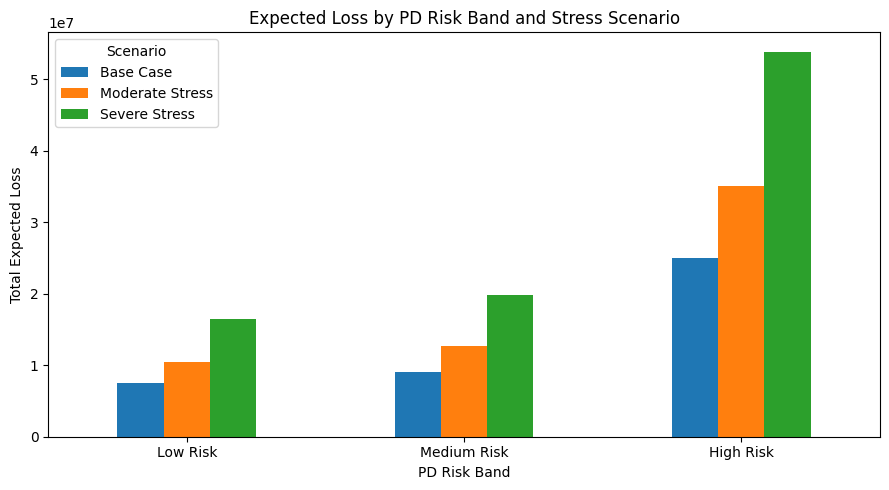

In [94]:
# =========================
# 7.5 Visualize Stress Test by Risk Band
# =========================

stress_pivot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Expected Loss by PD Risk Band and Stress Scenario")
plt.xlabel("PD Risk Band")
plt.ylabel("Total Expected Loss")
plt.xticks(rotation=0)
plt.legend(title="Scenario")
plt.tight_layout()
plt.show()

The stress test indicates that Expected Loss increases substantially under adverse scenarios. The High Risk segment contributes the largest share of stressed Expected Loss, which confirms that the PD risk segmentation is useful for portfolio risk monitoring.

This analysis is useful for management reporting because it shows not only the base-case expected loss, but also how sensitive the portfolio is to worsening credit conditions.

## Conclusion

This project demonstrates an end-to-end credit risk modeling workflow, from borrower-level Probability of Default estimation to portfolio-level Expected Loss assessment.

The final calibrated Random Forest model provides a balance between predictive performance and probability reliability. The model outputs are further translated into risk segments and stress scenarios to support credit portfolio monitoring.

Key lessons:
- Probability calibration is essential when predicted probabilities are used for loss estimation.
- Threshold selection should reflect business objectives rather than accuracy alone.
- Expected Loss depends not only on default probability but also on exposure and loss severity assumptions.